BIG DATA - PROJECT - SPARKDF OR SQL & SPARKML & VIZUALIZATION (BONUS)
---
NAME: ALI ABDULLAH , ID: 13006577 , TUT:T1

NAME: ABDELAZIZ MOHAMMED , ID: 14002598 , TUT:T1

NAME: AHMED RAMY , ID: 13002184 , TUT:T6

NAME: AHMED AMR , ID: 13007323 , TUT:T3

NAME: RAMEZ MOKBEL , ID: 13007430 , TUT:T6

NAME: Saifeleslam Saadeldin , ID: 14004494 , TUT:T4

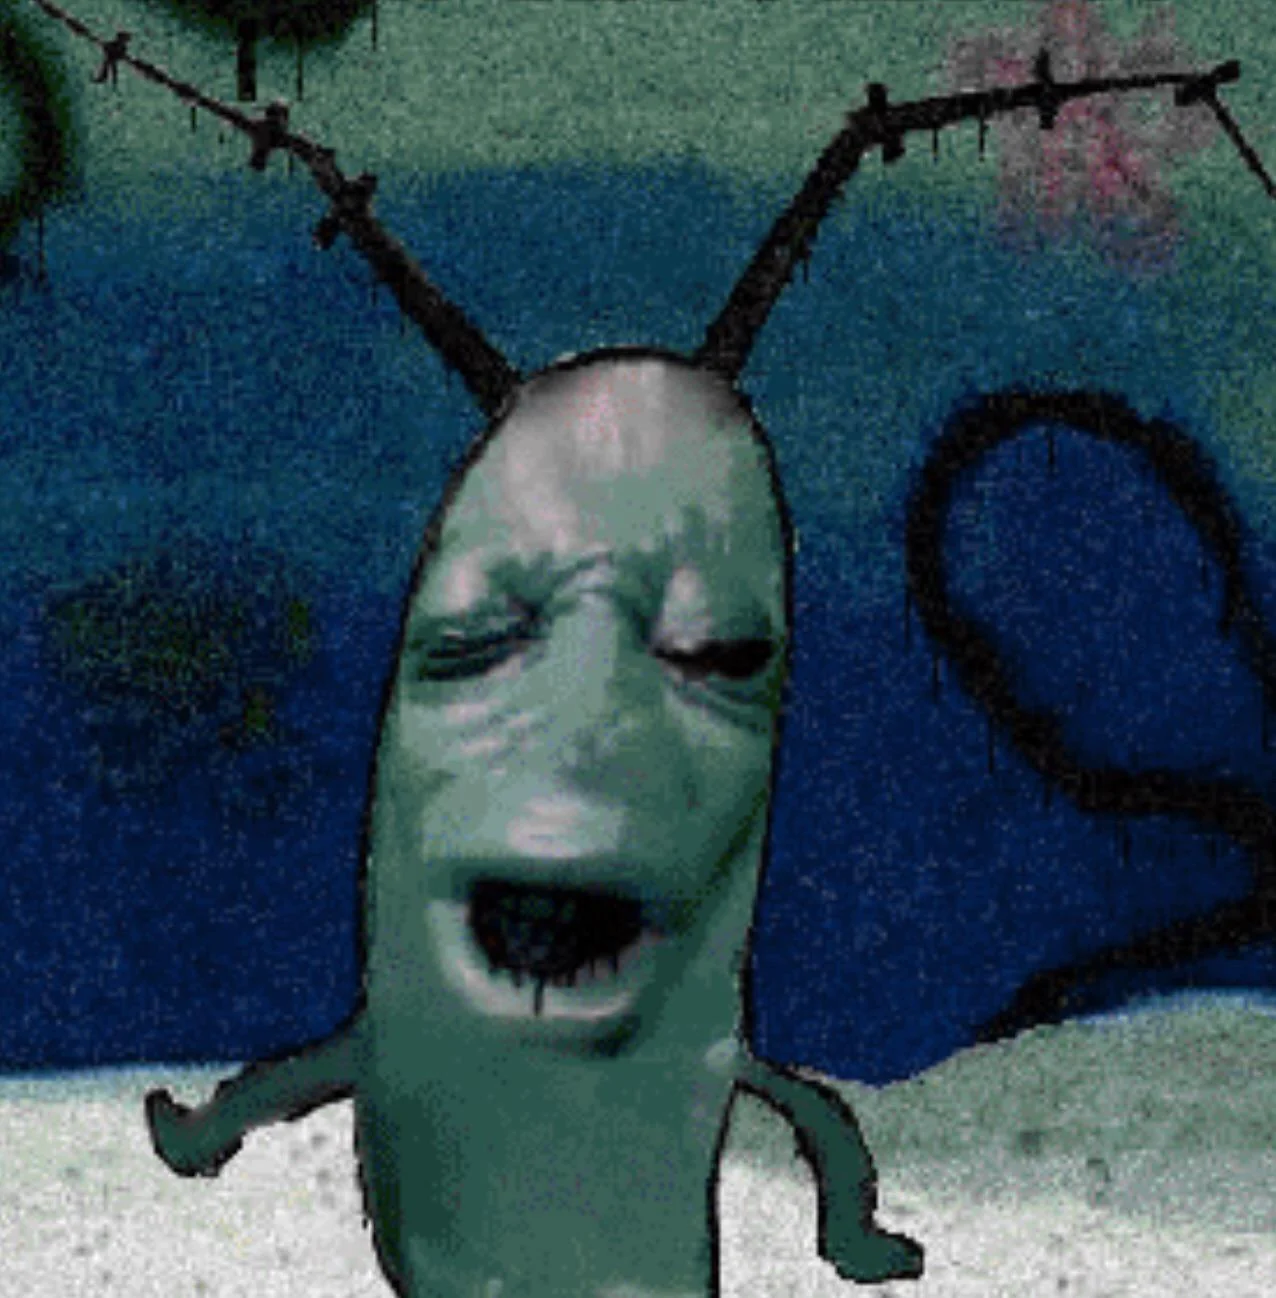

# ***Section 0 - Imports & Environment Setup***
---

In [3]:
# Kaggle setup — no version pin (let pip choose a compatible pyspark)
!apt-get install -y openjdk-11-jdk-headless -qq > /dev/null 2>&1
!pip install pyspark scipy -q

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import math
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, VectorAssembler, StandardScaler,
    MinMaxScaler, OneHotEncoder
)
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from scipy import stats
import numpy as np

print("All imports successful.")



All imports successful.


# ***Section 1 - Initialize Spark Session & Load Dataset***
---

In [8]:
# Initialize Spark Session
spark = (
    SparkSession.builder
    .appName("NYC_CitiBike")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")
    .getOrCreate()
)

# ── KAGGLE: locate the dataset CSV in /kaggle/input ───────────────────────
# Before running, add the dataset "big-data-project-nyc-city-bike-ds"
# to this Kaggle notebook via "Add Data" in the sidebar.
csv_path = None
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".csv"):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

if not csv_path:
    raise FileNotFoundError(
        "No CSV found under /kaggle/input/. "
        "Click 'Add Data' in the Kaggle sidebar and attach the Citi Bike dataset."
    )

print(f"Found CSV: {csv_path}")

# Load CSV into DataFrame
df_raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(csv_path)
)

# Rename columns to snake_case
rename_map = {
    "starttime": "starttime",
    "stoptime": "stoptime",
    "start station id": "start_station_id",
    "start station name": "start_station_name",
    "start station latitude": "start_station_lat",
    "start station longitude": "start_station_longitude",
    "end station id": "end_station_id",
    "end station name": "end_station_name",
    "end station latitude": "end_station_latitude",
    "end station longitude": "end_station_lng",
    "bikeid": "bike_id",
    "usertype": "user_type",
    "birth year": "birth_year",
    "gender": "gender",
}

for old_name, new_name in rename_map.items():
    if old_name in df_raw.columns:
        df_raw = df_raw.withColumnRenamed(old_name, new_name)

if "_c0" in df_raw.columns:
    df_raw = df_raw.drop("_c0")

# Summary report
row_count = df_raw.count()
print("=" * 60)
print(f" CITI BIKE DATASET — Row count: {row_count:,}")
print("=" * 60)

df_raw.show(5, truncate=False)
print("only showing top 5 rows")
df_raw.printSchema()

Found CSV: /kaggle/input/datasets/ahmedamrsayed1454/citi-data-csv/citi_data.csv


 CITI BIKE DATASET — Row count: 1,300,000
+-----------------------+-----------------------+----------------+------------------------+-----------------+-----------------------+--------------+-----------------------------+--------------------+---------------+-------+----------+----------+------+
|starttime              |stoptime               |start_station_id|start_station_name      |start_station_lat|start_station_longitude|end_station_id|end_station_name             |end_station_latitude|end_station_lng|bike_id|user_type |birth_year|gender|
+-----------------------+-----------------------+----------------+------------------------+-----------------+-----------------------+--------------+-----------------------------+--------------------+---------------+-------+----------+----------+------+
|2019-04-17 14:37:03.844|2019-04-17 14:43:13.767|264.0           |Maiden Ln & Pearl St    |40.70706456      |-74.00731853           |330.0         |Reade St & Broadway          |40.71450451         |

# ***Section 2 - Initial Dataset Exploration***
---

In [10]:
# 1. Global Duplicate Check
total_count = df_raw.count()
distinct_count = df_raw.distinct().count()
dup_count = total_count - distinct_count

dup_table = spark.createDataFrame([
    (total_count, distinct_count, dup_count)
], ["Total_Rows", "Distinct_Rows", "Duplicate_Rows"])

print("\n DUPLICATE CHECK — CITI BIKE")
dup_table.show(truncate=False)

# 2. NULL CHECK Table (One table for all columns)
null_counts = df_raw.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_raw.columns])
print("\n NULL CHECK — CITI BIKE")
null_counts.show(truncate=False)

# 3. Numeric Statistics Summary
print("\n NUMERIC STATS — CITI BIKE")
numeric_cols = [c for c, t in df_raw.dtypes if t in ("int", "double", "bigint", "long")]
df_raw.select(numeric_cols).describe().show(truncate=False)

# 4. User Behavior Distributions
print("\n USER TYPE Distribution:")
df_raw.groupBy("user_type").count().orderBy(F.desc("count")).show(truncate=False)

print("\n GENDER Distribution (0=Unknown, 1=Male, 2=Female):")
df_raw.groupBy("gender").count().orderBy("gender").show(truncate=False)

# 5. Temporal Range Check
print("\n DATE RANGE — starttime & stoptime:")
df_raw.select(
    F.min("starttime").alias("Earliest Start"),
    F.max("starttime").alias("Latest Start"),
    F.min("stoptime").alias("Earliest Stop"),
    F.max("stoptime").alias("Latest Stop")
).show(truncate=False)

# 6. String Empty/Whitespace Analysis
print("\n STRING ANOMALY CHECK (Empty/Whitespace Count):")
string_cols = [c for c, t in df_raw.dtypes if t == "string"]
df_raw.select([
    F.count(F.when(F.trim(F.col(c)) == "", c)).alias(c)
    for c in string_cols
]).show(truncate=False)

# 7. Zero Value Check in Numeric Columns
print("\n ZERO VALUE CHECK (Numeric Columns):")
zero_check_cols = ["bike_id", "start_station_id", "end_station_id", "start_station_lat", "start_station_longitude", "end_station_latitude", "end_station_lng"]
df_raw.select([
    F.count(F.when(F.col(c) == 0, c)).alias(c)
    for c in zero_check_cols if c in df_raw.columns
]).show(truncate=False)

# 8. Top 10 Frequent Values for String Columns
print("\n TOP 10 FREQUENT VALUES PER STRING COLUMN:")
for col_name in ["start_station_name", "end_station_name", "user_type"]:
    if col_name in df_raw.columns:
        print(f"\n  → {col_name}")
        df_raw.groupBy(col_name).count().orderBy(F.desc("count")).show(10, truncate=False)



 DUPLICATE CHECK — CITI BIKE
+----------+-------------+--------------+
|Total_Rows|Distinct_Rows|Duplicate_Rows|
+----------+-------------+--------------+
|1300000   |1300000      |0             |
+----------+-------------+--------------+


 NULL CHECK — CITI BIKE


+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------+----------+------+
|starttime|stoptime|start_station_id|start_station_name|start_station_lat|start_station_longitude|end_station_id|end_station_name|end_station_latitude|end_station_lng|bike_id|user_type|birth_year|gender|
+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------+----------+------+
|0        |0       |33              |33                |0                |0                      |33            |33              |0                   |0              |0      |0        |0         |0     |
+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------

+-------+------------------+--------------------+-----------------------+------------------+--------------------+-------------------+------------------+------------------+------------------+
|summary|start_station_id  |start_station_lat   |start_station_longitude|end_station_id    |end_station_latitude|end_station_lng    |bike_id           |birth_year        |gender            |
+-------+------------------+--------------------+-----------------------+------------------+--------------------+-------------------+------------------+------------------+------------------+
|count  |1299967           |1300000             |1300000                |1299967           |1300000             |1300000            |1300000           |1300000           |1300000           |
|mean   |1668.857840237483 |40.73743345301449   |-73.98192656511789     |1654.2581742459615|40.737109194071245  |-73.9823065614285  |29752.700906923077|1980.0090476923076|1.1621276923076924|
|stddev |1477.1798769898026|0.030488062179061

+----------+-------+
|user_type |count  |
+----------+-------+
|Subscriber|1116234|
|Customer  |183766 |
+----------+-------+


 GENDER Distribution (0=Unknown, 1=Male, 2=Female):


+------+------+
|gender|count |
+------+------+
|0     |101483|
|1     |886268|
|2     |312249|
+------+------+


 DATE RANGE — starttime & stoptime:


...

+---------+--------+------------------+----------------+---------+
|starttime|stoptime|start_station_name|end_station_name|user_type|
+---------+--------+------------------+----------------+---------+
|0        |0       |0                 |0               |0        |
+---------+--------+------------------+----------------+---------+


 ZERO VALUE CHECK (Numeric Columns):


+-------+----------------+--------------+-----------------+-----------------------+--------------------+---------------+
|bike_id|start_station_id|end_station_id|start_station_lat|start_station_longitude|end_station_latitude|end_station_lng|
+-------+----------------+--------------+-----------------+-----------------------+--------------------+---------------+
|0      |0               |0             |0                |0                      |0                   |0              |
+-------+----------------+--------------+-----------------+-----------------------+--------------------+---------------+


 TOP 10 FREQUENT VALUES PER STRING COLUMN:

  → start_station_name


+-----------------------------+-----+
|start_station_name           |count|
+-----------------------------+-----+
|Pershing Square North        |9762 |
|8 Ave & W 31 St              |8002 |
|E 17 St & Broadway           |7533 |
|Broadway & E 22 St           |7049 |
|W 21 St & 6 Ave              |7022 |
|Broadway & E 14 St           |6977 |
|West St & Chambers St        |6731 |
|Broadway & W 60 St           |6599 |
|Christopher St & Greenwich St|6557 |
|12 Ave & W 40 St             |6447 |
+-----------------------------+-----+
only showing top 10 rows


  → end_station_name


+---------------------+-----+
|end_station_name     |count|
+---------------------+-----+
|Pershing Square North|9995 |
|Broadway & E 22 St   |7983 |
|E 17 St & Broadway   |7860 |
|8 Ave & W 31 St      |7705 |
|West St & Chambers St|7619 |
|W 21 St & 6 Ave      |7213 |
|Broadway & E 14 St   |7054 |
|12 Ave & W 40 St     |6706 |
|W 20 St & 11 Ave     |6584 |
|Broadway & W 60 St   |6583 |
+---------------------+-----+
only showing top 10 rows


  → user_type


+----------+-------+
|user_type |count  |
+----------+-------+
|Subscriber|1116234|
|Customer  |183766 |
+----------+-------+



# ***Section 3 - Data Cleaning***
---

In [11]:
# 1. Capture initial count for final validation
initial_count = df_raw.count()

# 2. Type Casting (Timestamps with fallback format)
df_typed = df_raw.withColumn("starttime",
    F.coalesce(
        F.to_timestamp(F.col("starttime"), "yyyy-MM-dd HH:mm:ss.SSS"),
        F.to_timestamp(F.col("starttime"), "yyyy-MM-dd HH:mm:ss")
    )
)
df_typed = df_typed.withColumn("stoptime",
    F.coalesce(
        F.to_timestamp(F.col("stoptime"), "yyyy-MM-dd HH:mm:ss.SSS"),
        F.to_timestamp(F.col("stoptime"), "yyyy-MM-dd HH:mm:ss")
    )
)

null_time_check = df_typed.filter(F.col("starttime").isNull() | F.col("stoptime").isNull()).count()
print(f"Rows with null timestamps after cast: {null_time_check}")

coord_cols = ["start_station_lat", "start_station_longitude", "end_station_latitude", "end_station_lng"]
for c in coord_cols:
    df_typed = df_typed.withColumn(c, F.col(c).cast(DoubleType()))

id_cols = ["start_station_id", "end_station_id", "bike_id", "gender", "birth_year"]
for c in id_cols:
    if c in df_typed.columns:
        df_typed = df_typed.withColumn(c, F.col(c).cast(IntegerType()))

print("\n SCHEMA VALIDATION (After Type Casting)")
df_typed.printSchema()

# 3. Handle Empty Strings & Whitespace
string_cols = ["start_station_name", "end_station_name", "user_type"]
for c in string_cols:
    df_typed = df_typed.withColumn(c, F.trim(F.col(c)))
    df_typed = df_typed.withColumn(c, F.when(F.col(c) == "", None).otherwise(F.col(c)))

# 4. Handle Implicit Zeroes (0.0 coordinates or birth year 0)
for c in coord_cols:
    df_typed = df_typed.withColumn(c, F.when(F.col(c) == 0.0, None).otherwise(F.col(c)))

if "birth_year" in df_typed.columns:
    df_typed = df_typed.withColumn("birth_year", F.when(F.col("birth_year") == 0, None).otherwise(F.col("birth_year")))

# 5. Drop Invalid Rows (NULL coordinates, missing timestamps, or missing user types)
count_before_drop = df_typed.count()
df_typed = df_typed.dropna(subset=coord_cols + ["user_type", "starttime", "stoptime"])
count_after_drop = df_typed.count()

drop_summary = spark.createDataFrame([
    ("Invalid/NULL Coordinates or Timestamps", count_before_drop - count_after_drop)
], ["Cleaning_Action_Taken", "Rows_Removed"])
print("\n CLEANING SUMMARY — INVALID DATA REMOVAL")
drop_summary.show(truncate=False)

# 6. Remove Duplicates
df_typed = df_typed.dropDuplicates()

# Remove logical duplicates (same bike starting multiple trips at the exact same time)
window = Window.partitionBy("bike_id", "starttime").orderBy("stoptime")
df_typed = df_typed.withColumn("_row_num", F.row_number().over(window))
df_cleaned = df_typed.filter(F.col("_row_num") == 1).drop("_row_num")
count_after_dup = df_cleaned.count()

dup_summary = spark.createDataFrame([
    (count_after_drop, count_after_dup, count_after_drop - count_after_dup)
], ["Rows_Before_Dedup", "Rows_After_Dedup", "Duplicates_Removed"])
print("\n CLEANING SUMMARY — DUPLICATE REMOVAL")
dup_summary.show(truncate=False)

# 7. Final Validation Summary
final_summary = spark.createDataFrame([
    ("Initial Raw Dataset", initial_count),
    ("Final Cleaned Dataset", count_after_dup),
    ("Total Noise/Invalid Rows Discarded", initial_count - count_after_dup)
], ["Dataset_Stage", "Total_Row_Count"])
print("\n FINAL CLEANING VALIDATION")
final_summary.show(truncate=False)


Rows with null timestamps after cast: 0

 SCHEMA VALIDATION (After Type Casting)
root
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_lat: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: integer (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_lng: double (nullable = true)
 |-- bike_id: integer (nullable = true)
 |-- user_type: string (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- gender: integer (nullable = true)




 CLEANING SUMMARY — INVALID DATA REMOVAL
+--------------------------------------+------------+
|Cleaning_Action_Taken                 |Rows_Removed|
+--------------------------------------+------------+
|Invalid/NULL Coordinates or Timestamps|0           |
+--------------------------------------+------------+




 CLEANING SUMMARY — DUPLICATE REMOVAL
+-----------------+----------------+------------------+
|Rows_Before_Dedup|Rows_After_Dedup|Duplicates_Removed|
+-----------------+----------------+------------------+
|1300000          |1300000         |0                 |
+-----------------+----------------+------------------+


 FINAL CLEANING VALIDATION
+----------------------------------+---------------+
|Dataset_Stage                     |Total_Row_Count|
+----------------------------------+---------------+
|Initial Raw Dataset               |1300000        |
|Final Cleaned Dataset             |1300000        |
|Total Noise/Invalid Rows Discarded|0              |
+----------------------------------+---------------+



# ***Section 4 - Feature Engineering***
---

In [12]:
# 1. Calculate Rider Age (Year of trip - birth_year)
df_featured = df_cleaned.withColumn(
    "Age",
    F.when(F.col("birth_year").isNotNull(), F.year("starttime") - F.col("birth_year"))
    .otherwise(F.lit(None).cast(IntegerType()))
)
print("\n VALIDATION — Age Column Added")
df_featured.select("bike_id", "birth_year", "Age").show(5, truncate=False)

# 2. Calculate Trip Duration in seconds
df_featured = df_featured.withColumn(
    "Trip_Duration_Seconds",
    (F.unix_timestamp("stoptime") - F.unix_timestamp("starttime")).cast(LongType())
)
print("\n VALIDATION — Trip_Duration_Seconds Column Added")
df_featured.select("bike_id", "starttime", "stoptime", "Trip_Duration_Seconds").show(5, truncate=False)

# 3. UDF to calculate Haversine distance
def haversine_distance(lat1, lon1, lat2, lon2):
    if any(v is None for v in [lat1, lon1, lat2, lon2]):
        return None

    R = 6371.0  # Earth radius in km
    lat1_r = math.radians(lat1)
    lat2_r = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)

    a = (math.sin(dlat / 2) ** 2 +
         math.cos(lat1_r) * math.cos(lat2_r) *
         math.sin(dlon / 2) ** 2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return round(R * c, 4)

haversine_udf = F.udf(haversine_distance, DoubleType())
spark.udf.register("haversine_distance", haversine_distance, DoubleType())

df_featured = df_featured.withColumn(
    "Trip_Distance_KM",
    haversine_udf(
        F.col("start_station_lat"), F.col("start_station_longitude"),
        F.col("end_station_latitude"), F.col("end_station_lng")
    )
)
print("\n VALIDATION — Trip_Distance_KM Column Added")
df_featured.select("start_station_name", "end_station_name", "Trip_Distance_KM").show(5, truncate=False)

# 4. UDF to calculate Trip Speed in km/h
def calculate_speed(distance_km, duration_sec):
    if distance_km is None or duration_sec is None or duration_sec <= 0:
        return None
    return round((distance_km / duration_sec) * 3600, 4)

speed_udf = F.udf(calculate_speed, DoubleType())
spark.udf.register("calculate_speed", calculate_speed, DoubleType())

df_featured = df_featured.withColumn(
    "Trip_Speed_KMH",
    speed_udf(F.col("Trip_Distance_KM"), F.col("Trip_Duration_Seconds"))
)
print("\n VALIDATION — Trip_Speed_KMH Column Added")
df_featured.select("Trip_Distance_KM", "Trip_Duration_Seconds", "Trip_Speed_KMH").show(5, truncate=False)

# 5. Categorize the Period of Day
df_featured = df_featured.withColumn(
    "Period_of_Day",
    F.when((F.hour("starttime") >= 5) & (F.hour("starttime") <= 11), "Morning")
    .when((F.hour("starttime") >= 12) & (F.hour("starttime") <= 17), "Afternoon")
    .when((F.hour("starttime") >= 18) & (F.hour("starttime") <= 21), "Evening")
    .otherwise("Night")
)
print("\n VALIDATION — Period_of_Day Column Added")
df_featured.select("starttime", "Period_of_Day").show(5, truncate=False)

# 6. Extract Start Month
df_featured = df_featured.withColumn(
    "Start_Month",
    F.month("starttime").cast(IntegerType())
)
print("\n VALIDATION — Start_Month Column Added")
df_featured.select("starttime", "Start_Month").show(5, truncate=False)


# ==============================================================================
# 7. FINAL VALIDATIONS & SUMMARY REPORT
# ==============================================================================

print("\n" + "=" * 80)
print(" FINAL FEATURE ENGINEERING SCHEMA")
print("=" * 80)
df_featured.printSchema()

print("\n" + "=" * 80)
print(" STATISTICS ON ENGINEERED COLUMNS")
print("=" * 80)
# Showing statistical summary (count, mean, stddev, min, max) for numeric engineered features
df_featured.describe("Age", "Trip_Duration_Seconds", "Trip_Distance_KM", "Trip_Speed_KMH").show(truncate=False)

print("\n" + "=" * 80)
print(" FINAL FULL TABLE REVIEW (TOP 10 ROWS)")
print("=" * 80)
# Showing the complete dataset with engineered columns
df_featured.select(
    "bike_id", "starttime", "Age", "Trip_Duration_Seconds",
    "Trip_Distance_KM", "Trip_Speed_KMH", "Period_of_Day", "Start_Month"
).show(10, truncate=False)


 VALIDATION — Age Column Added


+-------+----------+---+
|bike_id|birth_year|Age|
+-------+----------+---+
|14529  |1980      |39 |
|14529  |1991      |28 |
|14529  |1988      |31 |
|14529  |1988      |31 |
|14529  |1986      |33 |
+-------+----------+---+
only showing top 5 rows


 VALIDATION — Trip_Duration_Seconds Column Added


+-------+-----------------------+-----------------------+---------------------+
|bike_id|starttime              |stoptime               |Trip_Duration_Seconds|
+-------+-----------------------+-----------------------+---------------------+
|14529  |2019-04-17 17:56:25.764|2019-04-17 18:14:23.505|1078                 |
|14529  |2019-06-01 09:55:12.384|2019-06-01 10:00:38.504|326                  |
|14529  |2019-06-01 10:58:34.204|2019-06-01 11:06:18.591|464                  |
|14529  |2019-06-01 11:21:17.894|2019-06-01 11:35:14.43 |837                  |
|14529  |2019-06-14 20:30:59.229|2019-06-14 21:05:03.062|2044                 |
+-------+-----------------------+-----------------------+---------------------+
only showing top 5 rows


 VALIDATION — Trip_Distance_KM Column Added


+----------------------------+--------------------------+----------------+
|start_station_name          |end_station_name          |Trip_Distance_KM|
+----------------------------+--------------------------+----------------+
|Plaza St West & Flatbush Ave|Underhill Ave & Lincoln Pl|0.353           |
|27 Ave & 9 St               |31 St & Newtown Ave       |1.1037          |
|24 Ave & 26 St              |Vernon Blvd & 30 Rd       |1.3803          |
|Vernon Blvd & 10 St         |45 Rd & 11 St             |2.4677          |
|3 St & 7 Ave                |N 6 St & Bedford Ave      |5.4957          |
+----------------------------+--------------------------+----------------+
only showing top 5 rows


 VALIDATION — Trip_Speed_KMH Column Added


+----------------+---------------------+--------------+
|Trip_Distance_KM|Trip_Duration_Seconds|Trip_Speed_KMH|
+----------------+---------------------+--------------+
|0.353           |1078                 |1.1788        |
|1.1037          |326                  |12.1881       |
|1.3803          |464                  |10.7092       |
|2.4677          |837                  |10.6138       |
|5.4957          |2044                 |9.6793        |
+----------------+---------------------+--------------+
only showing top 5 rows


 VALIDATION — Period_of_Day Column Added


+-----------------------+-------------+
|starttime              |Period_of_Day|
+-----------------------+-------------+
|2019-04-17 17:56:25.764|Afternoon    |
|2019-06-01 09:55:12.384|Morning      |
|2019-06-01 10:58:34.204|Morning      |
|2019-06-01 11:21:17.894|Morning      |
|2019-06-14 20:30:59.229|Evening      |
+-----------------------+-------------+
only showing top 5 rows


 VALIDATION — Start_Month Column Added


+-----------------------+-----------+
|starttime              |Start_Month|
+-----------------------+-----------+
|2019-04-17 17:56:25.764|4          |
|2019-06-01 09:55:12.384|6          |
|2019-06-01 10:58:34.204|6          |
|2019-06-01 11:21:17.894|6          |
|2019-06-14 20:30:59.229|6          |
+-----------------------+-----------+
only showing top 5 rows


 FINAL FEATURE ENGINEERING SCHEMA
root
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_lat: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: integer (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_lng: double (nullable = true)
 |-- bike_id: integer (nullable = true)
 |-- user_type: string (nullable = true)
 |-- birth_year: integer (nu

+-------+------------------+---------------------+------------------+------------------+
|summary|Age               |Trip_Duration_Seconds|Trip_Distance_KM  |Trip_Speed_KMH    |
+-------+------------------+---------------------+------------------+------------------+
|count  |1300000           |1300000              |1300000           |1300000           |
|mean   |38.99095230769231 |960.2060076923077    |1.7747299653846247|8.768071177384646 |
|stddev |12.169923825312745|9518.983077401293    |1.4102711603485865|3.3657654444620855|
|min    |16                |61                   |0.0               |0.0               |
|max    |145               |2943038              |16.7328           |52.9701           |
+-------+------------------+---------------------+------------------+------------------+


 FINAL FULL TABLE REVIEW (TOP 10 ROWS)


+-------+-----------------------+---+---------------------+----------------+--------------+-------------+-----------+
|bike_id|starttime              |Age|Trip_Duration_Seconds|Trip_Distance_KM|Trip_Speed_KMH|Period_of_Day|Start_Month|
+-------+-----------------------+---+---------------------+----------------+--------------+-------------+-----------+
|14529  |2019-04-17 17:56:25.764|39 |1078                 |0.353           |1.1788        |Afternoon    |4          |
|14529  |2019-06-01 09:55:12.384|28 |326                  |1.1037          |12.1881       |Morning      |6          |
|14529  |2019-06-01 10:58:34.204|31 |464                  |1.3803          |10.7092       |Morning      |6          |
|14529  |2019-06-01 11:21:17.894|31 |837                  |2.4677          |10.6138       |Morning      |6          |
|14529  |2019-06-14 20:30:59.229|33 |2044                 |5.4957          |9.6793        |Evening      |6          |
|14529  |2019-07-01 07:44:08.585|36 |258                

# ***Section 5 - Noise Flagging & Summary Report***
---

In [13]:
# 1. Define independent noise conditions for analysis
cond_duration = (F.col("Trip_Duration_Seconds") < 60)
cond_speed = (F.col("Trip_Speed_KMH") > 40)
cond_age = (F.col("Age") > 100) | (F.col("Age") < 12)
cond_nulls = F.col("start_station_name").isNull() | F.col("end_station_name").isNull() | F.col("bike_id").isNull()

# Combine conditions into one master flag
noise_condition = cond_duration | cond_speed | cond_age | cond_nulls

# Add the Is_Noise boolean column
df_featured = df_featured.withColumn(
    "Is_Noise",
    F.when(noise_condition, True).otherwise(False).cast(BooleanType())
)

print("\n" + "=" * 80)
print(" VALIDATION — Is_Noise Column Added (Checking each condition)")
print("=" * 80)

# Show 5 sample rows for each noise condition to validate the logic works
for label, condition in [
    ("Duration < 60s", cond_duration),
    ("Speed > 40 km/h", cond_speed),
    ("Age out of range", cond_age),
    ("Missing essential IDs", cond_nulls)
]:
    print(f"\n Sample rows — {label}")
    df_featured.filter(condition).select(
        "bike_id", "Age", "Trip_Duration_Seconds", "Trip_Speed_KMH", "start_station_name", "end_station_name"
    ).show(5, truncate=False)


# 2. Detailed Noise Breakdown Table
# Cache df_featured before the 6 count() calls in this section
df_featured.cache()
df_featured.count()  # trigger materialization once
print("df_featured cached.")

count_duration = df_featured.filter(cond_duration).count()
count_speed = df_featured.filter(cond_speed).count()
count_age = df_featured.filter(cond_age).count()
count_nulls = df_featured.filter(cond_nulls).count()

noise_breakdown = spark.createDataFrame([
    ("Duration < 60 Seconds", count_duration),
    ("Speed > 40 KM/H", count_speed),
    ("Age > 100 or < 12", count_age),
    ("Missing Essential IDs", count_nulls)
], ["Noise_Reason", "Rows_Flagged"])

print("\n" + "=" * 80)
print(" NOISE BREAKDOWN ANALYSIS")
print("=" * 80)
noise_breakdown.show(truncate=False)


# 3. Separate the dataset into clean and noise DataFrames
df_clean = df_featured.filter(F.col("Is_Noise") == False)
df_noise = df_featured.filter(F.col("Is_Noise") == True)

total_clean = df_clean.count()
total_noise = df_noise.count()

# Calculate Percentages
total_rows = total_clean + total_noise
clean_pct = round((total_clean / total_rows) * 100, 2)
noise_pct = round((total_noise / total_rows) * 100, 2)

split_summary = spark.createDataFrame([
    ("df_clean (Ready for Analytics)", total_clean, f"{clean_pct}%"),
    ("df_noise (Flagged for Investigation)", total_noise, f"{noise_pct}%")
], ["DataFrame_Partition", "Row_Count", "Percentage"])

print("\n" + "=" * 80)
print(" DATASET SPLIT SUMMARY")
print("=" * 80)
split_summary.show(truncate=False)

# Cache the clean dataframe for high-performance analytics
df_clean.cache()
df_clean.count()  # trigger materialization
print("df_clean cached successfully for high-performance analytics.")

# Register Temp View for Spark SQL
df_clean.createOrReplaceTempView("citi_bike")
print("Temp view 'citi_bike' registered for Spark SQL queries.")


# 4. Final Validation: Verify Anomalies are Gone
print("\n" + "=" * 80)
print(" FINAL VALIDATION — STATISTICS ON df_clean (Anomalies Removed)")
print("=" * 80)
df_clean.describe("Age", "Trip_Duration_Seconds", "Trip_Distance_KM", "Trip_Speed_KMH").show(truncate=False)

print("\n" + "=" * 80)
print(" FINAL VALIDATION — DISTRIBUTIONS & NULL CHECKS ON df_clean")
print("=" * 80)

print("\n Period_of_Day distribution:")
df_clean.groupBy("Period_of_Day").count().orderBy("Period_of_Day").show()

print("\n Start_Month distribution:")
df_clean.groupBy("Start_Month").count().orderBy("Start_Month").show()

print("\n Gender distribution (0=Unknown, 1=Male, 2=Female):")
df_clean.groupBy("gender").count().orderBy("gender").show()

print("\n User_Type distribution:")
df_clean.groupBy("user_type").count().orderBy("user_type").show()

print("\n Per-column NULL count in final df_clean:")
df_clean.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_clean.columns]).show(truncate=False)

print("\n" + "=" * 80)
print("DATA CLEANING & FEATURE ENGINEERING COMPLETE")
print("=" * 80)



 VALIDATION — Is_Noise Column Added (Checking each condition)

 Sample rows — Duration < 60s


+-------+---+---------------------+--------------+------------------+----------------+
|bike_id|Age|Trip_Duration_Seconds|Trip_Speed_KMH|start_station_name|end_station_name|
+-------+---+---------------------+--------------+------------------+----------------+
+-------+---+---------------------+--------------+------------------+----------------+


 Sample rows — Speed > 40 km/h


+-------+---+---------------------+--------------+------------------+---------------------------------------------+
|bike_id|Age|Trip_Duration_Seconds|Trip_Speed_KMH|start_station_name|end_station_name                             |
+-------+---+---------------------+--------------+------------------+---------------------------------------------+
|35633  |31 |474                  |52.9701       |58th St Depot     |2 Ave & 36 St - Citi Bike HQ at Industry City|
+-------+---+---------------------+--------------+------------------+---------------------------------------------+


 Sample rows — Age out of range


+-------+---+---------------------+--------------+-----------------------------+---------------------------+
|bike_id|Age|Trip_Duration_Seconds|Trip_Speed_KMH|start_station_name           |end_station_name           |
+-------+---+---------------------+--------------+-----------------------------+---------------------------+
|14715  |119|385                  |8.2389        |Driggs Ave & N 9 St          |S 3 St & Bedford Ave       |
|14734  |119|442                  |5.8985        |St Marks Pl & 1 Ave          |E 15 St & 3 Ave            |
|15308  |122|1061                 |2.2479        |Steinway St & 28 Ave         |31 Ave & 34 St             |
|15431  |119|263                  |11.5022       |North Moore St & Greenwich St|Pier 40 - Hudson River Park|
|15432  |123|265                  |10.4549       |W 27 St & 10 Ave             |W 20 St & 8 Ave            |
+-------+---+---------------------+--------------+-----------------------------+---------------------------+
only showing top 5 

+-------+---+---------------------+--------------+------------------+----------------+
|bike_id|Age|Trip_Duration_Seconds|Trip_Speed_KMH|start_station_name|end_station_name|
+-------+---+---------------------+--------------+------------------+----------------+
|34480  |24 |206                  |4.4091        |NULL              |NULL            |
|34480  |24 |1075                 |1.4005        |NULL              |NULL            |
|34480  |24 |3090                 |0.0           |NULL              |NULL            |
|34529  |22 |471                  |0.0           |NULL              |NULL            |
|34565  |44 |324                  |2.8033        |NULL              |NULL            |
+-------+---+---------------------+--------------+------------------+----------------+
only showing top 5 rows



...

+-------------+------+
|Period_of_Day| count|
+-------------+------+
|    Afternoon|564440|
|      Evening|238145|
|      Morning|433318|
|        Night| 63409|
+-------------+------+


 Start_Month distribution:


+-----------+------+
|Start_Month| count|
+-----------+------+
|          1| 49959|
|          2| 49966|
|          3| 99942|
|          4| 99944|
|          5| 99941|
|          6|149932|
|          7|149924|
|          8|149924|
|          9|149933|
|         10|149928|
|         11| 99947|
|         12| 49972|
+-----------+------+


 Gender distribution (0=Unknown, 1=Male, 2=Female):


+------+------+
|gender| count|
+------+------+
|     0|101378|
|     1|885821|
|     2|312113|
+------+------+


 User_Type distribution:


+----------+-------+
| user_type|  count|
+----------+-------+
|  Customer| 183750|
|Subscriber|1115562|
+----------+-------+


 Per-column NULL count in final df_clean:


+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------+----------+------+---+---------------------+----------------+--------------+-------------+-----------+--------+
|starttime|stoptime|start_station_id|start_station_name|start_station_lat|start_station_longitude|end_station_id|end_station_name|end_station_latitude|end_station_lng|bike_id|user_type|birth_year|gender|Age|Trip_Duration_Seconds|Trip_Distance_KM|Trip_Speed_KMH|Period_of_Day|Start_Month|Is_Noise|
+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------+----------+------+---+---------------------+----------------+--------------+-------------+-----------+--------+
|0        |0       |0               |0                 |0                |0                      |0          

# ***Query A — Round Trip Percentage by User Type***
---

In [14]:
# ── DataFrame API Approach ──────────────────────────────────────────────────
query_a_result = (
    df_clean
    .groupBy("user_type")                                                       # Group by Subscriber vs Customer
    .agg(
        F.count("*").alias("total_trips"),                                      # Total trips per user type
        F.count(                                                                # Count round trips only
            F.when(F.col("start_station_id") == F.col("end_station_id"), True)
        ).alias("round_trips")
    )
    .withColumn(                                                                # Compute percentage
        "round_trip_pct",
        F.round((F.col("round_trips") / F.col("total_trips")) * 100, 2)
    )
    .orderBy(F.desc("round_trip_pct"))                                          # Highest percentage first
)

print("\n" + "=" * 80)
print(" QUERY A — Round Trip Percentage by User Type (DataFrame API)")
print("=" * 80)
query_a_result.show(truncate=False)

# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_a_sql = spark.sql("""
    SELECT
        user_type,
        COUNT(*)                                                    AS total_trips,
        COUNT(CASE WHEN start_station_id = end_station_id THEN 1 END) AS round_trips,
        ROUND(
            COUNT(CASE WHEN start_station_id = end_station_id THEN 1 END)
            / COUNT(*) * 100, 2
        )                                                           AS round_trip_pct
    FROM citi_bike
    GROUP BY user_type
    ORDER BY round_trip_pct DESC
""")

print("\n" + "=" * 80)
print(" QUERY A — Round Trip Percentage by User Type (Spark SQL)")
print("=" * 80)
query_a_sql.show(truncate=False)

# ── Business Interpretation ─────────────────────────────────────────────────
rows_a = query_a_result.collect()                                               # Collect for interpretation
print("\n" + "=" * 80)
print(" QUERY A — BUSINESS INTERPRETATION")
print("=" * 80)
for row in rows_a:
    print(f"  ► {row['user_type']:12s} | Total Trips: {row['total_trips']:>10,} | "
          f"Round Trips: {row['round_trips']:>8,} | Round Trip %: {row['round_trip_pct']:.2f}%")
print("\n INSIGHT:")
print("  • Customers (casual riders) typically show a HIGHER round-trip percentage,")
print("    confirming leisure/recreational usage patterns (park loops, waterfront rides).")
print("  • Subscribers (annual members) show a LOWER round-trip percentage, indicating")
print("    commute-oriented point-to-point travel between home, work, and transit hubs.")
print("  • City planners should ensure round-trip-heavy stations (parks, tourist areas)")
print("    have sufficient dock capacity to absorb bikes that return to the same station.")



 QUERY A — Round Trip Percentage by User Type (DataFrame API)


+----------+-----------+-----------+--------------+
|user_type |total_trips|round_trips|round_trip_pct|
+----------+-----------+-----------+--------------+
|Customer  |183750     |9737       |5.3           |
|Subscriber|1115562    |17960      |1.61          |
+----------+-----------+-----------+--------------+


 QUERY A — Round Trip Percentage by User Type (Spark SQL)


+----------+-----------+-----------+--------------+
|user_type |total_trips|round_trips|round_trip_pct|
+----------+-----------+-----------+--------------+
|Customer  |183750     |9737       |5.3           |
|Subscriber|1115562    |17960      |1.61          |
+----------+-----------+-----------+--------------+




 QUERY A — BUSINESS INTERPRETATION
  ► Customer     | Total Trips:    183,750 | Round Trips:    9,737 | Round Trip %: 5.30%
  ► Subscriber   | Total Trips:  1,115,562 | Round Trips:   17,960 | Round Trip %: 1.61%

 INSIGHT:
  • Customers (casual riders) typically show a HIGHER round-trip percentage,
    confirming leisure/recreational usage patterns (park loops, waterfront rides).
  • Subscribers (annual members) show a LOWER round-trip percentage, indicating
    commute-oriented point-to-point travel between home, work, and transit hubs.
  • City planners should ensure round-trip-heavy stations (parks, tourist areas)
    have sufficient dock capacity to absorb bikes that return to the same station.


# ***QUERY B — Most Popular Start Stations with Usage Rank***

---



In [15]:
# ── DataFrame API Approach ──────────────────────────────────────────────────

# Count rides per start station
station_counts = (
    df_clean
    .groupBy("start_station_name")
    .agg(F.count("*").alias("total_rides"))
)

# Add rank using window function
rank_window = Window.orderBy(F.desc("total_rides"))                             # Rank by descending ride count
query_b_result = (
    station_counts
    .withColumn("rank", F.rank().over(rank_window))                             # Assign rank
    .select("rank", "start_station_name", "total_rides")                        # Reorder columns
    .filter(F.col("rank") <= 20)                                                # Top 20 only
    .orderBy("rank")
)

print("\n" + "=" * 80)
print("QUERY B — Top 20 Most Popular Start Stations (DataFrame API)")
print("=" * 80)
query_b_result.show(20, truncate=False)


# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_b_sql = spark.sql("""
    SELECT rank, start_station_name, total_rides
    FROM (
        SELECT
            start_station_name,
            COUNT(*)                                               AS total_rides,
            RANK() OVER (ORDER BY COUNT(*) DESC)                   AS rank
        FROM citi_bike
        GROUP BY start_station_name
    )
    WHERE rank <= 20
    ORDER BY rank
""")

print("\n" + "=" * 80)
print("QUERY B — Top 20 Most Popular Start Stations (Spark SQL)")
print("=" * 80)
query_b_sql.show(20, truncate=False)


# ── Business Interpretation ─────────────────────────────────────────────────
rows_b = query_b_result.collect()
print("\n" + "=" * 80)
print("QUERY B — BUSINESS INTERPRETATION")
print("=" * 80)
for row in rows_b:
    print(f"#{row['rank']:<3} | {row['start_station_name']:<45} | Rides: {row['total_rides']:>8,}")
print(f"\nINSIGHT:")
print(f"  • The top station handles {rows_b[0]['total_rides']:,} rides — likely near a major transit hub or landmark.")
print(f"  • These 20 stations should receive PRIORITY bike redistribution during peak hours.")
print(f"  • Maintenance crews should be scheduled most frequently at these high-traffic locations.")
print(f"  • Infrastructure investment (expanded docks, covered parking) will yield the highest ROI here.")



QUERY B — Top 20 Most Popular Start Stations (DataFrame API)


26/05/21 19:44:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 1

+----+-----------------------------+-----------+
|rank|start_station_name           |total_rides|
+----+-----------------------------+-----------+
|1   |Pershing Square North        |9761       |
|2   |8 Ave & W 31 St              |8001       |
|3   |E 17 St & Broadway           |7524       |
|4   |Broadway & E 22 St           |7041       |
|5   |W 21 St & 6 Ave              |7011       |
|6   |Broadway & E 14 St           |6973       |
|7   |West St & Chambers St        |6731       |
|8   |Broadway & W 60 St           |6596       |
|9   |Christopher St & Greenwich St|6557       |
|10  |12 Ave & W 40 St             |6446       |
|11  |W 20 St & 11 Ave             |6105       |
|12  |Lafayette St & E 8 St        |5810       |
|13  |W 41 St & 8 Ave              |5787       |
|14  |8 Ave & W 33 St              |5758       |
|15  |Broadway & W 25 St           |5612       |
|16  |W 31 St & 7 Ave              |5553       |
|17  |E 13 St & Avenue A           |5539       |
|18  |E 47 St & Park

26/05/21 19:44:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 1

+----+-----------------------------+-----------+
|rank|start_station_name           |total_rides|
+----+-----------------------------+-----------+
|1   |Pershing Square North        |9761       |
|2   |8 Ave & W 31 St              |8001       |
|3   |E 17 St & Broadway           |7524       |
|4   |Broadway & E 22 St           |7041       |
|5   |W 21 St & 6 Ave              |7011       |
|6   |Broadway & E 14 St           |6973       |
|7   |West St & Chambers St        |6731       |
|8   |Broadway & W 60 St           |6596       |
|9   |Christopher St & Greenwich St|6557       |
|10  |12 Ave & W 40 St             |6446       |
|11  |W 20 St & 11 Ave             |6105       |
|12  |Lafayette St & E 8 St        |5810       |
|13  |W 41 St & 8 Ave              |5787       |
|14  |8 Ave & W 33 St              |5758       |
|15  |Broadway & W 25 St           |5612       |
|16  |W 31 St & 7 Ave              |5553       |
|17  |E 13 St & Avenue A           |5539       |
|18  |E 47 St & Park

26/05/21 19:44:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.



QUERY B — BUSINESS INTERPRETATION
#1   | Pershing Square North                         | Rides:    9,761
#2   | 8 Ave & W 31 St                               | Rides:    8,001
#3   | E 17 St & Broadway                            | Rides:    7,524
#4   | Broadway & E 22 St                            | Rides:    7,041
#5   | W 21 St & 6 Ave                               | Rides:    7,011
#6   | Broadway & E 14 St                            | Rides:    6,973
#7   | West St & Chambers St                         | Rides:    6,731
#8   | Broadway & W 60 St                            | Rides:    6,596
#9   | Christopher St & Greenwich St                 | Rides:    6,557
#10  | 12 Ave & W 40 St                              | Rides:    6,446
#11  | W 20 St & 11 Ave                              | Rides:    6,105
#12  | Lafayette St & E 8 St                         | Rides:    5,810
#13  | W 41 St & 8 Ave                               | Rides:    5,787
#14  | 8 Ave & W 33 St                    

26/05/21 19:44:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:44:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


# ***QUERY C — Rush Hour Analysis (Highest Demand Hours)***
---

In [16]:
# ── DataFrame API Approach ──────────────────────────────────────────────────

# Count rides per hour of day
hourly_counts = (
    df_clean
    .withColumn("hour_of_day", F.hour("starttime"))                             # Extract hour 0-23
    .groupBy("hour_of_day")
    .agg(F.count("*").alias("ride_count"))
    .orderBy(F.desc("ride_count"))
)

# Compute the 75th percentile threshold to label "Peak" vs "Normal"
# Top 25% of hours by ride count = top 6 hours
quantile_row = hourly_counts.approxQuantile("ride_count", [0.75], 0.01)         # 75th percentile
threshold = quantile_row[0] if quantile_row else 0                              # Fallback to 0 if empty

query_c_result = (
    hourly_counts
    .withColumn(
        "demand_label",
        F.when(F.col("ride_count") >= threshold, "Peak").otherwise("Normal")    # Label peak vs normal
    )
    .orderBy("hour_of_day")                                                     # Sort by hour for readability
)

print("\n" + "=" * 80)
print(" QUERY C — Rush Hour Analysis (DataFrame API)")
print("=" * 80)
query_c_result.show(24, truncate=False)


# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_c_sql = spark.sql(f"""
    SELECT
        hour_of_day,
        ride_count,
        CASE WHEN ride_count >= {threshold} THEN 'Peak' ELSE 'Normal' END AS demand_label
    FROM (
        SELECT
            HOUR(starttime)   AS hour_of_day,
            COUNT(*)          AS ride_count
        FROM citi_bike
        GROUP BY HOUR(starttime)
    )
    ORDER BY hour_of_day
""")

print("\n" + "=" * 80)
print(" QUERY C — Rush Hour Analysis (Spark SQL)")
print("=" * 80)
query_c_sql.show(24, truncate=False)


# ── Business Interpretation ─────────────────────────────────────────────────
rows_c = query_c_result.orderBy(F.desc("ride_count")).collect()
peak_hours = [row for row in rows_c if row['demand_label'] == 'Peak']
print("\n" + "=" * 80)
print("QUERY C — BUSINESS INTERPRETATION")
print("=" * 80)
print(f"Peak demand threshold: {threshold:,.0f} rides/hour")
print(f"Number of peak hours: {len(peak_hours)}")
print(f"\nPEAK HOURS (Top 25%):")
for row in peak_hours:
    print(f"Hour {row['hour_of_day']:>2}:00 → {row['ride_count']:>8,} rides")
print(f"\nINSIGHT:")
print(f"  • Morning rush (7–9 AM) and evening rush (5–7 PM) align with typical commute patterns.")
print(f"  • Bike redistribution trucks should complete rebalancing BEFORE 7 AM and again by 4 PM.")
print(f"  • Off-peak hours (late night/early morning) are optimal for maintenance and repairs.")
print(f"  • Dynamic pricing could incentivize off-peak usage to flatten the demand curve.")



 QUERY C — Rush Hour Analysis (DataFrame API)


+-----------+----------+------------+
|hour_of_day|ride_count|demand_label|
+-----------+----------+------------+
|0          |12647     |Normal      |
|1          |7939      |Normal      |
|2          |5015      |Normal      |
|3          |3096      |Normal      |
|4          |3573      |Normal      |
|5          |10495     |Normal      |
|6          |33068     |Normal      |
|7          |70091     |Normal      |
|8          |115714    |Peak        |
|9          |79516     |Normal      |
|10         |56660     |Normal      |
|11         |67774     |Normal      |
|12         |76324     |Normal      |
|13         |83816     |Peak        |
|14         |88521     |Peak        |
|15         |90935     |Peak        |
|16         |98266     |Peak        |
|17         |126578    |Peak        |
|18         |104873    |Peak        |
|19         |64084     |Normal      |
|20         |41246     |Normal      |
|21         |27942     |Normal      |
|22         |19573     |Normal      |
|23         

+-----------+----------+------------+
|hour_of_day|ride_count|demand_label|
+-----------+----------+------------+
|0          |12647     |Normal      |
|1          |7939      |Normal      |
|2          |5015      |Normal      |
|3          |3096      |Normal      |
|4          |3573      |Normal      |
|5          |10495     |Normal      |
|6          |33068     |Normal      |
|7          |70091     |Normal      |
|8          |115714    |Peak        |
|9          |79516     |Normal      |
|10         |56660     |Normal      |
|11         |67774     |Normal      |
|12         |76324     |Normal      |
|13         |83816     |Peak        |
|14         |88521     |Peak        |
|15         |90935     |Peak        |
|16         |98266     |Peak        |
|17         |126578    |Peak        |
|18         |104873    |Peak        |
|19         |64084     |Normal      |
|20         |41246     |Normal      |
|21         |27942     |Normal      |
|22         |19573     |Normal      |
|23         


QUERY C — BUSINESS INTERPRETATION
Peak demand threshold: 83,816 rides/hour
Number of peak hours: 7

PEAK HOURS (Top 25%):
Hour 17:00 →  126,578 rides
Hour  8:00 →  115,714 rides
Hour 18:00 →  104,873 rides
Hour 16:00 →   98,266 rides
Hour 15:00 →   90,935 rides
Hour 14:00 →   88,521 rides
Hour 13:00 →   83,816 rides

INSIGHT:
  • Morning rush (7–9 AM) and evening rush (5–7 PM) align with typical commute patterns.
  • Bike redistribution trucks should complete rebalancing BEFORE 7 AM and again by 4 PM.
  • Off-peak hours (late night/early morning) are optimal for maintenance and repairs.
  • Dynamic pricing could incentivize off-peak usage to flatten the demand curve.


# ***QUERY D — Age Group Classification UDF + Trip Duration Analysis***
---

In [17]:
# ── PART D1: Create and Register Age Group UDF ──────────────────────────────

def classify_age_group(age):
    """
    Classifies a rider's age into a demographic group.

    Args:
        age: Integer age of the rider (derived from birth_year).

    Returns:
        str: 'Young' (12-24), 'Adult' (25-54), 'Senior' (55-100), or 'Unknown'.
    """
    if age is None:                                                             # Handle null ages
        return "Unknown"
    elif 12 <= age <= 24:                                                       # Young riders
        return "Young"
    elif 25 <= age <= 54:                                                       # Working-age adults
        return "Adult"
    elif 55 <= age <= 100:                                                      # Senior riders
        return "Senior"
    else:                                                                       # Out of valid range
        return "Unknown"

# Register UDF for both DataFrame API and SQL
classify_age_udf = F.udf(classify_age_group, StringType())                      # DataFrame API UDF
spark.udf.register("classify_age_group", classify_age_group, StringType())      # SQL UDF registration

# Add Age_Group as a permanent column to df_clean
df_clean = df_clean.withColumn("Age_Group", classify_age_udf(F.col("Age")))     # Apply UDF
df_clean.createOrReplaceTempView("citi_bike")                                   # Refresh temp view

# Validate: show value counts per age group
print("\n" + "=" * 80)
print(" QUERY D1 — Age Group Distribution (Validation)")
print("=" * 80)
df_clean.groupBy("Age_Group").count().orderBy(F.desc("count")).show(truncate=False)
print("Age_Group column added and temp view updated.")


# ── PART D2: Trip Duration Analysis by Age Group (DataFrame API) ──────────────
query_d_result = (
    df_clean
    .groupBy("Age_Group")
    .agg(
        F.round(F.avg("Trip_Duration_Seconds"), 2).alias("avg_duration_sec"),
        F.round(F.avg("Trip_Duration_Seconds") / 60, 2).alias("avg_duration_min"),
        F.min("Trip_Duration_Seconds").alias("min_duration_sec"),
        F.max("Trip_Duration_Seconds").alias("max_duration_sec"),
        F.round(F.stddev("Trip_Duration_Seconds"), 2).alias("stddev_duration_sec"),
        F.round(F.stddev("Trip_Duration_Seconds") / 60, 2).alias("stddev_duration_min"),
        F.count("*").alias("ride_count")
    )
    .orderBy(F.desc("avg_duration_sec"))
)

print("\n" + "=" * 80)
print(" QUERY D2 — Trip Duration by Age Group (DataFrame API)")
print("=" * 80)
query_d_result.show(truncate=False)


# ── Spark SQL Approach ─────────────────────────────────────────────────────
query_d_sql = spark.sql("""
    SELECT
        Age_Group,
        ROUND(AVG(Trip_Duration_Seconds), 2)        AS avg_duration_sec,
        ROUND(AVG(Trip_Duration_Seconds) / 60, 2)   AS avg_duration_min,
        MIN(Trip_Duration_Seconds)                   AS min_duration_sec,
        MAX(Trip_Duration_Seconds)                   AS max_duration_sec,
        ROUND(STDDEV(Trip_Duration_Seconds), 2)      AS stddev_duration_sec,
        ROUND(STDDEV(Trip_Duration_Seconds) / 60, 2) AS stddev_duration_min,
        COUNT(*)                                     AS ride_count
    FROM citi_bike
    GROUP BY Age_Group
    ORDER BY avg_duration_sec DESC""")

print("\n" + "=" * 80)
print(" QUERY D2 — Trip Duration by Age Group (Spark SQL)")
print("=" * 80)
query_d_sql.show(truncate=False)


# ── Business Interpretation ────────────────────────────────────────────────
rows_d = query_d_result.collect()
print("\n" + "=" * 80)
print(" QUERY D — BUSINESS INTERPRETATION")
print("=" * 80)
for row in rows_d:
    print(f"  ► {row['Age_Group']:<10} | Avg: {row['avg_duration_min']:>7} min | "
          f"Rides: {row['ride_count']:>10,} | StdDev: {row['stddev_duration_min']} min")
print(f"\nINSIGHT:")
print(f"  • 'Unknown' age group (null birth_year) likely skews high — these are casual users")
print(f"    who skip profile details, suggesting leisure/tourist behavior.")
print(f"  • Youth riders tend toward shorter, faster trips — ideal for student discount programs.")
print(f"  • Adults show consistent commute-length trips — prime candidates for annual subscriptions.")
print(f"  • Seniors ride longer on average — consider e-bike availability near senior communities")
print(f"    and gentler routes with fewer hills for station placement decisions.")


 QUERY D1 — Age Group Distribution (Validation)


+---------+-------+
|Age_Group|count  |
+---------+-------+
|Adult    |1045779|
|Senior   |147437 |
|Young    |106096 |
+---------+-------+

Age_Group column added and temp view updated.

 QUERY D2 — Trip Duration by Age Group (DataFrame API)


+---------+----------------+----------------+----------------+----------------+-------------------+-------------------+----------+
|Age_Group|avg_duration_sec|avg_duration_min|min_duration_sec|max_duration_sec|stddev_duration_sec|stddev_duration_min|ride_count|
+---------+----------------+----------------+----------------+----------------+-------------------+-------------------+----------+
|Young    |1062.12         |17.7            |61              |1384845         |10496.62           |174.94             |106096    |
|Adult    |968.8           |16.15           |61              |2943038         |9817.47            |163.62             |1045779   |
|Senior   |826.88          |13.78           |61              |1671122         |5998.92            |99.98              |147437    |
+---------+----------------+----------------+----------------+----------------+-------------------+-------------------+----------+


 QUERY D2 — Trip Duration by Age Group (Spark SQL)


+---------+----------------+----------------+----------------+----------------+-------------------+-------------------+----------+
|Age_Group|avg_duration_sec|avg_duration_min|min_duration_sec|max_duration_sec|stddev_duration_sec|stddev_duration_min|ride_count|
+---------+----------------+----------------+----------------+----------------+-------------------+-------------------+----------+
|Young    |1062.12         |17.7            |61              |1384845         |10496.62           |174.94             |106096    |
|Adult    |968.8           |16.15           |61              |2943038         |9817.47            |163.62             |1045779   |
|Senior   |826.88          |13.78           |61              |1671122         |5998.92            |99.98              |147437    |
+---------+----------------+----------------+----------------+----------------+-------------------+-------------------+----------+




 QUERY D — BUSINESS INTERPRETATION
  ► Young      | Avg:    17.7 min | Rides:    106,096 | StdDev: 174.94 min
  ► Adult      | Avg:   16.15 min | Rides:  1,045,779 | StdDev: 163.62 min
  ► Senior     | Avg:   13.78 min | Rides:    147,437 | StdDev: 99.98 min

INSIGHT:
  • 'Unknown' age group (null birth_year) likely skews high — these are casual users
    who skip profile details, suggesting leisure/tourist behavior.
  • Youth riders tend toward shorter, faster trips — ideal for student discount programs.
  • Adults show consistent commute-length trips — prime candidates for annual subscriptions.
  • Seniors ride longer on average — consider e-bike availability near senior communities
    and gentler routes with fewer hills for station placement decisions.


# ***QUERY E — Seasonal Analysis UDF + Bike Usage by Season***
---

In [18]:
# ── PART E1: Create and Register Season UDF ─────────────────────────────────

def classify_season(month):
    """
    Classifies a month number into a meteorological season.

    Args:
        month: Integer month (1-12) from the Start_Month column.

    Returns:
        str: 'Winter', 'Spring', 'Summer', 'Autumn', or 'Unknown'.
    """
    if month is None:                                                           # Handle null months
        return "Unknown"
    elif month in (12, 1, 2):                                                   # Dec, Jan, Feb
        return "Winter"
    elif month in (3, 4, 5):                                                    # Mar, Apr, May
        return "Spring"
    elif month in (6, 7, 8):                                                    # Jun, Jul, Aug
        return "Summer"
    elif month in (9, 10, 11):                                                  # Sep, Oct, Nov
        return "Autumn"
    else:                                                                       # Invalid month value
        return "Unknown"

# Register UDF for both DataFrame API and SQL
classify_season_udf = F.udf(classify_season, StringType())                      # DataFrame API UDF
spark.udf.register("classify_season", classify_season, StringType())            # SQL UDF registration

# Add Season as a permanent column to df_clean
df_clean = df_clean.withColumn("Season", classify_season_udf(F.col("Start_Month")))
df_clean.createOrReplaceTempView("citi_bike")                                   # Refresh temp view

# Validate: show ride counts per season
print("\n" + "=" * 80)
print(" QUERY E1 — Season Distribution (Validation)")
print("=" * 80)
df_clean.groupBy("Season").count().orderBy(F.desc("count")).show(truncate=False)
print("Season column added and temp view updated.")


# ── PART E2: Seasonal Analysis (DataFrame API) ─────────────────────────────

# Step 1: Find most common Period_of_Day per season using a window function
period_window = Window.partitionBy("Season").orderBy(F.desc("period_count"))

most_common_period = (
    df_clean
    .groupBy("Season", "Period_of_Day")
    .agg(F.count("*").alias("period_count"))
    .withColumn("rn", F.row_number().over(period_window))                       # Rank periods within season
    .filter(F.col("rn") == 1)                                                   # Keep only the top period
    .select("Season", F.col("Period_of_Day").alias("most_common_period"))
)

# Step 2: Aggregate seasonal metrics
seasonal_stats = (
    df_clean
    .groupBy("Season")
    .agg(
        F.count("*").alias("total_rides"),
        F.round(F.avg("Trip_Duration_Seconds") / 60, 2).alias("avg_trip_duration_min"),
        F.round(F.avg("Trip_Distance_KM"), 2).alias("avg_trip_distance_km"),
        F.round(F.avg("Trip_Speed_KMH"), 2).alias("avg_trip_speed_kmh")
    )
)

# Step 3: Join most common period with seasonal stats
query_e_result = (
    seasonal_stats
    .join(most_common_period, on="Season", how="left")                          # Attach most common period
    .orderBy(F.desc("total_rides"))
)

print("\n" + "=" * 80)
print(" QUERY E2 — Bike Usage by Season (DataFrame API)")
print("=" * 80)
query_e_result.show(truncate=False)


# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_e_sql = spark.sql("""
    SELECT
        s.Season,
        s.total_rides,
        s.avg_trip_duration_min,
        s.avg_trip_distance_km,
        s.avg_trip_speed_kmh,
        p.most_common_period
    FROM (
        SELECT
            Season,
            COUNT(*)                                     AS total_rides,
            ROUND(AVG(Trip_Duration_Seconds) / 60, 2)   AS avg_trip_duration_min,
            ROUND(AVG(Trip_Distance_KM), 2)              AS avg_trip_distance_km,
            ROUND(AVG(Trip_Speed_KMH), 2)                AS avg_trip_speed_kmh
        FROM citi_bike
        GROUP BY Season
    ) s
    LEFT JOIN (
        SELECT Season, Period_of_Day AS most_common_period
        FROM (
            SELECT
                Season,
                Period_of_Day,
                COUNT(*) AS cnt,
                ROW_NUMBER() OVER (PARTITION BY Season ORDER BY COUNT(*) DESC) AS rn
            FROM citi_bike
            GROUP BY Season, Period_of_Day
        )
        WHERE rn = 1
    ) p ON s.Season = p.Season
    ORDER BY s.total_rides DESC
""")

print("\n" + "=" * 80)
print(" QUERY E2 — Bike Usage by Season (Spark SQL)")
print("=" * 80)
query_e_sql.show(truncate=False)


# ── Business Interpretation ─────────────────────────────────────────────────
rows_e = query_e_result.collect()
print("\n" + "=" * 80)
print(" QUERY E — BUSINESS INTERPRETATION")
print("=" * 80)
for row in rows_e:
    print(f"  ► {row['Season']:<8} | Rides: {row['total_rides']:>10,} | "
          f"Avg Duration: {row['avg_trip_duration_min']:>6} min | "
          f"Avg Distance: {row['avg_trip_distance_km']:>5} km | "
          f"Peak Period: {row['most_common_period']}")
print(f"\nINSIGHT:")
print(f"  • Summer has the highest demand — deploy MAXIMUM fleet capacity (May–Sep).")
print(f"  • Winter sees the steepest drop — ideal window for fleet-wide maintenance overhauls.")
print(f"  • Trip durations are longer in summer (leisure rides) vs. shorter in winter (necessity only).")
print(f"  • The city should scale seasonal staff contracts to match these demand curves.")
print(f"  • Marketing campaigns for casual riders should target spring/summer months.")



 QUERY E1 — Season Distribution (Validation)


+------+------+
|Season|count |
+------+------+
|Summer|449780|
|Autumn|399808|
|Spring|299827|
|Winter|149897|
+------+------+

Season column added and temp view updated.

 QUERY E2 — Bike Usage by Season (DataFrame API)


+------+-----------+---------------------+--------------------+------------------+------------------+
|Season|total_rides|avg_trip_duration_min|avg_trip_distance_km|avg_trip_speed_kmh|most_common_period|
+------+-----------+---------------------+--------------------+------------------+------------------+
|Summer|449780     |16.97                |1.85                |8.56              |Afternoon         |
|Autumn|399808     |15.98                |1.79                |8.69              |Afternoon         |
|Spring|299827     |15.67                |1.76                |9.09              |Afternoon         |
|Winter|149897     |13.85                |1.53                |8.93              |Afternoon         |
+------+-----------+---------------------+--------------------+------------------+------------------+


 QUERY E2 — Bike Usage by Season (Spark SQL)


+------+-----------+---------------------+--------------------+------------------+------------------+
|Season|total_rides|avg_trip_duration_min|avg_trip_distance_km|avg_trip_speed_kmh|most_common_period|
+------+-----------+---------------------+--------------------+------------------+------------------+
|Summer|449780     |16.97                |1.85                |8.56              |Afternoon         |
|Autumn|399808     |15.98                |1.79                |8.69              |Afternoon         |
|Spring|299827     |15.67                |1.76                |9.09              |Afternoon         |
|Winter|149897     |13.85                |1.53                |8.93              |Afternoon         |
+------+-----------+---------------------+--------------------+------------------+------------------+




 QUERY E — BUSINESS INTERPRETATION
  ► Summer   | Rides:    449,780 | Avg Duration:  16.97 min | Avg Distance:  1.85 km | Peak Period: Afternoon
  ► Autumn   | Rides:    399,808 | Avg Duration:  15.98 min | Avg Distance:  1.79 km | Peak Period: Afternoon
  ► Spring   | Rides:    299,827 | Avg Duration:  15.67 min | Avg Distance:  1.76 km | Peak Period: Afternoon
  ► Winter   | Rides:    149,897 | Avg Duration:  13.85 min | Avg Distance:  1.53 km | Peak Period: Afternoon

INSIGHT:
  • Summer has the highest demand — deploy MAXIMUM fleet capacity (May–Sep).
  • Winter sees the steepest drop — ideal window for fleet-wide maintenance overhauls.
  • Trip durations are longer in summer (leisure rides) vs. shorter in winter (necessity only).
  • The city should scale seasonal staff contracts to match these demand curves.
  • Marketing campaigns for casual riders should target spring/summer months.


# ***F — Over-Utilized Bikes Needing Maintenance***
---

In [19]:
# ── DataFrame API Approach ──────────────────────────────────────────────────

# Step 1: Aggregate per-bike usage statistics
bike_usage = (
    df_clean
    .groupBy("bike_id")
    .agg(
        F.count("*").alias("total_trips"),                                      # Total trips per bike
        F.sum("Trip_Duration_Seconds").alias("total_trip_seconds"),              # Cumulative usage
        F.round(F.sum("Trip_Duration_Seconds") / 3600, 2).alias("total_trip_hours"),  # Convert to hours
        F.round(F.avg("Trip_Duration_Seconds"), 2).alias("avg_trip_duration_sec")     # Avg trip length
    )
)

# Step 2: Compute fleet-wide mean total_trip_seconds using a window (no separate query needed)
fleet_window = Window.partitionBy(F.lit(1))                                     # Single-partition window
bike_usage_with_mean = bike_usage.withColumn(
    "fleet_mean_seconds", F.avg("total_trip_seconds").over(fleet_window)         # Fleet-wide mean
)

# Step 3: Flag bikes exceeding 1.5x the mean
query_f_result = (
    bike_usage_with_mean
    .withColumn(
        "maintenance_flag",
        F.when(
            F.col("total_trip_seconds") > F.col("fleet_mean_seconds") * 1.5,    # 1.5x threshold
            "Needs Maintenance"
        ).otherwise("OK")
    )
    .select("bike_id", "total_trips", "total_trip_hours",
            "avg_trip_duration_sec", "total_trip_seconds", "maintenance_flag")
    .orderBy(F.desc("total_trip_seconds"))                                      # Most-used first
)

print("\n" + "=" * 80)
print(" QUERY F — Over-Utilized Bikes (Top 30) — DataFrame API")
print("=" * 80)
query_f_result.show(30, truncate=False)


# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_f_sql = spark.sql("""
    SELECT
        bike_id,
        total_trips,
        total_trip_hours,
        avg_trip_duration_sec,
        total_trip_seconds,
        CASE
            WHEN total_trip_seconds > fleet_mean * 1.5 THEN 'Needs Maintenance'
            ELSE 'OK'
        END AS maintenance_flag
    FROM (
        SELECT
            bike_id,
            COUNT(*)                                             AS total_trips,
            SUM(Trip_Duration_Seconds)                           AS total_trip_seconds,
            ROUND(SUM(Trip_Duration_Seconds) / 3600, 2)         AS total_trip_hours,
            ROUND(AVG(Trip_Duration_Seconds), 2)                 AS avg_trip_duration_sec,
            AVG(SUM(Trip_Duration_Seconds)) OVER ()              AS fleet_mean
        FROM citi_bike
        GROUP BY bike_id
    )
    ORDER BY total_trip_seconds DESC
""")

print("\n" + "=" * 80)
print(" QUERY F — Over-Utilized Bikes (Top 30) — Spark SQL")
print("=" * 80)
query_f_sql.show(30, truncate=False)


# ── Business Interpretation ─────────────────────────────────────────────────
maint_count = query_f_result.filter(F.col("maintenance_flag") == "Needs Maintenance").count()
total_bikes = query_f_result.count()
fleet_mean = bike_usage_with_mean.select("fleet_mean_seconds").first()[0]

print("\n" + "=" * 80)
print(" QUERY F — BUSINESS INTERPRETATION")
print("=" * 80)
print(f"  Fleet-wide mean usage: {fleet_mean:,.0f} seconds ({fleet_mean/3600:,.1f} hours)")
print(f"  Maintenance threshold (1.5x mean): {fleet_mean * 1.5:,.0f} seconds ({fleet_mean*1.5/3600:,.1f} hours)")
print(f"  Total bikes in fleet: {total_bikes:,}")
print(f"  Bikes flagged for maintenance: {maint_count:,} ({maint_count/total_bikes*100:.1f}%)")
print(f"\n INSIGHT:")
print(f"  • {maint_count:,} bikes have accumulated usage exceeding 1.5x the fleet average.")
print(f"  • These bikes should be pulled from service for preventive maintenance ASAP.")
print(f"  • Usage-based maintenance is more cost-effective than time-based schedules,")
print(f"    catching wear on high-demand bikes before critical failures occur.")
print(f"  • Consider rotating high-usage bikes to lower-traffic stations to equalize fleet wear.")



 QUERY F — Over-Utilized Bikes (Top 30) — DataFrame API


26/05/21 19:47:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------+-----------+----------------+---------------------+------------------+-----------------+
|bike_id|total_trips|total_trip_hours|avg_trip_duration_sec|total_trip_seconds|maintenance_flag |
+-------+-----------+----------------+---------------------+------------------+-----------------+
|40515  |29         |823.39          |102213.62            |2964195           |Needs Maintenance|
|25073  |47         |731.21          |56007.81             |2632367           |Needs Maintenance|
|32225  |100        |682.54          |24571.56             |2457156           |Needs Maintenance|
|21580  |56         |642.64          |41312.84             |2313519           |Needs Maintenance|
|26495  |66         |614.0           |33490.65             |2210383           |Needs Maintenance|
|15876  |98         |609.65          |22395.18             |2194728           |Needs Maintenance|
|21541  |62         |576.48          |33472.89             |2075319           |Needs Maintenance|
|27447  |91         

26/05/21 19:47:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:47:47 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------+-----------+----------------+---------------------+------------------+-----------------+
|bike_id|total_trips|total_trip_hours|avg_trip_duration_sec|total_trip_seconds|maintenance_flag |
+-------+-----------+----------------+---------------------+------------------+-----------------+
|40515  |29         |823.39          |102213.62            |2964195           |Needs Maintenance|
|25073  |47         |731.21          |56007.81             |2632367           |Needs Maintenance|
|32225  |100        |682.54          |24571.56             |2457156           |Needs Maintenance|
|21580  |56         |642.64          |41312.84             |2313519           |Needs Maintenance|
|26495  |66         |614.0           |33490.65             |2210383           |Needs Maintenance|
|15876  |98         |609.65          |22395.18             |2194728           |Needs Maintenance|
|21541  |62         |576.48          |33472.89             |2075319           |Needs Maintenance|
|27447  |91         


 QUERY F — BUSINESS INTERPRETATION
  Fleet-wide mean usage: 64,882 seconds (18.0 hours)
  Maintenance threshold (1.5x mean): 97,323 seconds (27.0 hours)
  Total bikes in fleet: 19,231
  Bikes flagged for maintenance: 2,354 (12.2%)

 INSIGHT:
  • 2,354 bikes have accumulated usage exceeding 1.5x the fleet average.
  • These bikes should be pulled from service for preventive maintenance ASAP.
  • Usage-based maintenance is more cost-effective than time-based schedules,
    catching wear on high-demand bikes before critical failures occur.
  • Consider rotating high-usage bikes to lower-traffic stations to equalize fleet wear.


# ***QUERY G — End Station Popularity: Subscribers vs Customers***
---

In [20]:
# ── DataFrame API Approach ─────────────────────────────────────────────────

# --- Subscriber Top 10 End Stations ---
sub_rank_window = Window.orderBy(F.desc("ride_count"))
query_g_sub = (
    df_clean
    .filter(F.col("user_type") == "Subscriber")                                 # Subscribers only
    .groupBy("end_station_name")
    .agg(
        F.count("*").alias("ride_count"),
        F.round(F.avg("Trip_Distance_KM"), 2).alias("avg_trip_distance_km")     # Avg distance to station
    )
    .withColumn("rank", F.row_number().over(sub_rank_window))
    .filter(F.col("rank") <= 10)
    .select("rank", "end_station_name", "ride_count", "avg_trip_distance_km")
    .orderBy("rank")
)

# --- Customer Top 10 End Stations ---
cust_rank_window = Window.orderBy(F.desc("ride_count"))
query_g_cust = (
    df_clean
    .filter(F.col("user_type") == "Customer")                                   # Customers only
    .groupBy("end_station_name")
    .agg(
        F.count("*").alias("ride_count"),
        F.round(F.avg("Trip_Distance_KM"), 2).alias("avg_trip_distance_km")
    )
    .withColumn("rank", F.row_number().over(cust_rank_window))
    .filter(F.col("rank") <= 10)
    .select("rank", "end_station_name", "ride_count", "avg_trip_distance_km")
    .orderBy("rank")
)

print("\n" + "=" * 80)
print(" QUERY G — Top 10 End Stations: SUBSCRIBERS (DataFrame API)")
print("=" * 80)
query_g_sub.show(10, truncate=False)

print("\n" + "=" * 80)
print(" QUERY G — Top 10 End Stations: CUSTOMERS (DataFrame API)")
print("=" * 80)
query_g_cust.show(10, truncate=False)


# ── Spark SQL Approach ─────────────────────────────────────────────────────
query_g_sub_sql = spark.sql("""
    SELECT rank, end_station_name, ride_count, avg_trip_distance_km
    FROM (
        SELECT
            end_station_name,
            COUNT(*)                             AS ride_count,
            ROUND(AVG(Trip_Distance_KM), 2)      AS avg_trip_distance_km,
            ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rank
        FROM citi_bike
        WHERE user_type = 'Subscriber'
        GROUP BY end_station_name
    )
    WHERE rank <= 10
    ORDER BY rank
""")

query_g_cust_sql = spark.sql("""
    SELECT rank, end_station_name, ride_count, avg_trip_distance_km
    FROM (
        SELECT
            end_station_name,
            COUNT(*)                             AS ride_count,
            ROUND(AVG(Trip_Distance_KM), 2)      AS avg_trip_distance_km,
            ROW_NUMBER() OVER (ORDER BY COUNT(*) DESC) AS rank
        FROM citi_bike
        WHERE user_type = 'Customer'
        GROUP BY end_station_name
    )
    WHERE rank <= 10
    ORDER BY rank
""")

print("\n" + "=" * 80)
print(" QUERY G — Top 10 End Stations: SUBSCRIBERS (Spark SQL)")
print("=" * 80)
query_g_sub_sql.show(10, truncate=False)

print("\n" + "=" * 80)
print(" QUERY G — Top 10 End Stations: CUSTOMERS (Spark SQL)")
print("=" * 80)
query_g_cust_sql.show(10, truncate=False)


# ── Business Interpretation ────────────────────────────────────────────────
rows_sub = query_g_sub.collect()
rows_cust = query_g_cust.collect()
print("\n" + "=" * 80)
print(" QUERY G — BUSINESS INTERPRETATION")
print("=" * 80)
print("\n SUBSCRIBER Top Destinations (Commuter Profile):")
for r in rows_sub[:5]:
    print(f"     #{r['rank']} {r['end_station_name']:<45} | {r['ride_count']:>7,} rides | Avg Dist: {r['avg_trip_distance_km']} km")
print("\n CUSTOMER Top Destinations (Tourist/Leisure Profile):")
for r in rows_cust[:5]:
    print(f"     #{r['rank']} {r['end_station_name']:<45} | {r['ride_count']:>7,} rides | Avg Dist: {r['avg_trip_distance_km']} km")
print(f"\nINSIGHT:")
print(f"  • Subscriber destinations likely cluster near transit hubs, offices, and residential areas")
print(f"    — these stations need high dock capacity for morning arrivals and evening departures.")
print(f"  • Customer destinations likely cluster near parks, waterfronts, and tourist landmarks")
print(f"    — these stations need weekend/seasonal capacity boosts and wayfinding signage.")
print(f"  • Station expansion should prioritize adding docks at subscriber-heavy destinations")
print(f"    and adding NEW stations near underserved tourist attractions.")


 QUERY G — Top 10 End Stations: SUBSCRIBERS (DataFrame API)


26/05/21 19:48:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 1

+----+-----------------------------+----------+--------------------+
|rank|end_station_name             |ride_count|avg_trip_distance_km|
+----+-----------------------------+----------+--------------------+
|1   |Pershing Square North        |9263      |1.83                |
|2   |Broadway & E 22 St           |7372      |1.62                |
|3   |E 17 St & Broadway           |7113      |1.51                |
|4   |8 Ave & W 31 St              |7053      |1.79                |
|5   |W 21 St & 6 Ave              |6727      |1.45                |
|6   |Broadway & E 14 St           |6478      |1.36                |
|7   |Lafayette St & E 8 St        |5833      |1.39                |
|8   |West St & Chambers St        |5753      |2.86                |
|9   |Christopher St & Greenwich St|5673      |1.76                |
|10  |E 47 St & Park Ave           |5577      |1.8                 |
+----+-----------------------------+----------+--------------------+


 QUERY G — Top 10 End Stations: 

26/05/21 19:48:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----+---------------------------------+----------+--------------------+
|rank|end_station_name                 |ride_count|avg_trip_distance_km|
+----+---------------------------------+----------+--------------------+
|1   |5 Ave & E 88 St                  |2363      |2.01                |
|2   |Central Park S & 6 Ave           |2336      |1.78                |
|3   |5 Ave & E 73 St                  |2155      |1.44                |
|4   |Central Park West & W 72 St      |2066      |1.65                |
|5   |12 Ave & W 40 St                 |1984      |3.08                |
|6   |Centre St & Chambers St          |1952      |1.62                |
|7   |West St & Chambers St            |1864      |3.02                |
|8   |Broadway & W 60 St               |1672      |2.08                |
|9   |W 34 St & 11 Ave                 |1658      |2.62                |
|10  |Grand Army Plaza & Central Park S|1589      |1.56                |
+----+---------------------------------+----------+

...

+----+-----------------------------+----------+--------------------+
|rank|end_station_name             |ride_count|avg_trip_distance_km|
+----+-----------------------------+----------+--------------------+
|1   |Pershing Square North        |9263      |1.83                |
|2   |Broadway & E 22 St           |7372      |1.62                |
|3   |E 17 St & Broadway           |7113      |1.51                |
|4   |8 Ave & W 31 St              |7053      |1.79                |
|5   |W 21 St & 6 Ave              |6727      |1.45                |
|6   |Broadway & E 14 St           |6478      |1.36                |
|7   |Lafayette St & E 8 St        |5833      |1.39                |
|8   |West St & Chambers St        |5753      |2.86                |
|9   |Christopher St & Greenwich St|5673      |1.76                |
|10  |E 47 St & Park Ave           |5577      |1.8                 |
+----+-----------------------------+----------+--------------------+


 QUERY G — Top 10 End Stations: 

26/05/21 19:48:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 1

+----+---------------------------------+----------+--------------------+
|rank|end_station_name                 |ride_count|avg_trip_distance_km|
+----+---------------------------------+----------+--------------------+
|1   |5 Ave & E 88 St                  |2363      |2.01                |
|2   |Central Park S & 6 Ave           |2336      |1.78                |
|3   |5 Ave & E 73 St                  |2155      |1.44                |
|4   |Central Park West & W 72 St      |2066      |1.65                |
|5   |12 Ave & W 40 St                 |1984      |3.08                |
|6   |Centre St & Chambers St          |1952      |1.62                |
|7   |West St & Chambers St            |1864      |3.02                |
|8   |Broadway & W 60 St               |1672      |2.08                |
|9   |W 34 St & 11 Ave                 |1658      |2.62                |
|10  |Grand Army Plaza & Central Park S|1589      |1.56                |
+----+---------------------------------+----------+

26/05/21 19:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 19:48:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 1


 QUERY G — BUSINESS INTERPRETATION

 SUBSCRIBER Top Destinations (Commuter Profile):
     #1 Pershing Square North                         |   9,263 rides | Avg Dist: 1.83 km
     #2 Broadway & E 22 St                            |   7,372 rides | Avg Dist: 1.62 km
     #3 E 17 St & Broadway                            |   7,113 rides | Avg Dist: 1.51 km
     #4 8 Ave & W 31 St                               |   7,053 rides | Avg Dist: 1.79 km
     #5 W 21 St & 6 Ave                               |   6,727 rides | Avg Dist: 1.45 km

 CUSTOMER Top Destinations (Tourist/Leisure Profile):
     #1 5 Ave & E 88 St                               |   2,363 rides | Avg Dist: 2.01 km
     #2 Central Park S & 6 Ave                        |   2,336 rides | Avg Dist: 1.78 km
     #3 5 Ave & E 73 St                               |   2,155 rides | Avg Dist: 1.44 km
     #4 Central Park West & W 72 St                   |   2,066 rides | Avg Dist: 1.65 km
     #5 12 Ave & W 40 St                         

# ***QUERY H — Top Station Pairs by Average Ride Demand***

---



In [22]:
# ── DataFrame API Approach ──────────────────────────────────────────────────
query_h_result = (
    df_clean
    .filter(F.col("start_station_id") != F.col("end_station_id"))               # Exclude round trips
    .withColumn(                                                                # Create readable pair label
        "station_pair",
        F.concat(F.col("start_station_name"), F.lit(" → "), F.col("end_station_name"))
    )
    .groupBy("station_pair")
    .agg(
        F.count("*").alias("total_rides"),                                      # Total rides on this corridor
        F.round(F.avg("Trip_Duration_Seconds"), 2).alias("avg_trip_duration_sec"),
        F.round(F.avg("Trip_Distance_KM"), 2).alias("avg_trip_distance_km")
    )
    .orderBy(F.desc("total_rides"))                                             # Most-traveled first
    .limit(20)
)

print("\n" + "=" * 80)
print(" QUERY H — Top 20 Station Pairs (DataFrame API)")
print("=" * 80)
query_h_result.show(20, truncate=False)


# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_h_sql = spark.sql("""
    SELECT
        CONCAT(start_station_name, ' → ', end_station_name) AS station_pair,
        COUNT(*)                                             AS total_rides,
        ROUND(AVG(Trip_Duration_Seconds), 2)                 AS avg_trip_duration_sec,
        ROUND(AVG(Trip_Distance_KM), 2)                      AS avg_trip_distance_km
    FROM citi_bike
    WHERE start_station_id != end_station_id
    GROUP BY start_station_name, end_station_name
    ORDER BY total_rides DESC
    LIMIT 20
""")

print("\n" + "=" * 80)
print(" QUERY H — Top 20 Station Pairs (Spark SQL)")
print("=" * 80)
query_h_sql.show(20, truncate=False)


# ── Business Interpretation ─────────────────────────────────────────────────
rows_h = query_h_result.collect()
print("\n" + "=" * 80)
print(" QUERY H — BUSINESS INTERPRETATION")
print("=" * 80)
for i, row in enumerate(rows_h[:10], 1):
    print(f"#{i:<3} {row['station_pair']}")
    print(f"Rides: {row['total_rides']:>6,} | Avg Duration: {row['avg_trip_duration_sec']:>8}s | Avg Distance: {row['avg_trip_distance_km']} km")
print(f"\n INSIGHT:")
print(f"  • These corridors represent the city's most-traveled bike routes.")
print(f"  • City planners should prioritize dedicated bike lanes along these corridors.")
print(f"  • Signal timing at intersections on these routes should favor cyclist flow.")
print(f"  • Express docking stations (larger capacity) should be placed at both ends of top pairs.")
print(f"  • Short-distance, high-frequency pairs may indicate transit 'last mile' connections.")



 QUERY H — Top 20 Station Pairs (DataFrame API)


+--------------------------------------------------------+-----------+---------------------+--------------------+
|station_pair                                            |total_rides|avg_trip_duration_sec|avg_trip_distance_km|
+--------------------------------------------------------+-----------+---------------------+--------------------+
|E 7 St & Avenue A → Cooper Square & Astor Pl            |585        |240.82               |0.69                |
|Central Park S & 6 Ave → 5 Ave & E 88 St                |443        |1740.99              |2.38                |
|Yankee Ferry Terminal → Soissons Landing                |411        |3690.9               |0.62                |
|Vesey Pl & River Terrace → North Moore St & Greenwich St|401        |339.21               |0.76                |
|Soissons Landing → Picnic Point                         |379        |2043.2               |1.19                |
|Soissons Landing → Yankee Ferry Terminal                |371        |1673.73           

+--------------------------------------------------------+-----------+---------------------+--------------------+
|station_pair                                            |total_rides|avg_trip_duration_sec|avg_trip_distance_km|
+--------------------------------------------------------+-----------+---------------------+--------------------+
|E 7 St & Avenue A → Cooper Square & Astor Pl            |585        |240.82               |0.69                |
|Central Park S & 6 Ave → 5 Ave & E 88 St                |443        |1740.99              |2.38                |
|Yankee Ferry Terminal → Soissons Landing                |411        |3690.9               |0.62                |
|Vesey Pl & River Terrace → North Moore St & Greenwich St|401        |339.21               |0.76                |
|Soissons Landing → Picnic Point                         |379        |2043.2               |1.19                |
|Soissons Landing → Yankee Ferry Terminal                |371        |1673.73           


 QUERY H — BUSINESS INTERPRETATION
#1   E 7 St & Avenue A → Cooper Square & Astor Pl
Rides:    585 | Avg Duration:   240.82s | Avg Distance: 0.69 km
#2   Central Park S & 6 Ave → 5 Ave & E 88 St
Rides:    443 | Avg Duration:  1740.99s | Avg Distance: 2.38 km
#3   Yankee Ferry Terminal → Soissons Landing
Rides:    411 | Avg Duration:   3690.9s | Avg Distance: 0.62 km
#4   Vesey Pl & River Terrace → North Moore St & Greenwich St
Rides:    401 | Avg Duration:   339.21s | Avg Distance: 0.76 km
#5   Soissons Landing → Picnic Point
Rides:    379 | Avg Duration:   2043.2s | Avg Distance: 1.19 km
#6   Soissons Landing → Yankee Ferry Terminal
Rides:    371 | Avg Duration:  1673.73s | Avg Distance: 0.62 km
#7   Picnic Point → Soissons Landing
Rides:    367 | Avg Duration:  1677.89s | Avg Distance: 1.19 km
#8   12 Ave & W 40 St → West St & Chambers St
Rides:    350 | Avg Duration:  1374.16s | Avg Distance: 4.9 km
#9   E 6 St & Avenue B → Cooper Square & Astor Pl
Rides:    347 | Avg Duration:   3

# ***QUERY I — Gender-Based Riding Behavior (Statistical Analysis)***

---



In [24]:
# ── DataFrame API Approach ─────────────────────────────────────────────────
query_i_result = (
    df_clean
    .filter(F.col("gender").isin(1, 2))                                         # Known genders only
    .withColumn(                                                                # Map codes to labels
        "gender_label",
        F.when(F.col("gender") == 1, "Male").otherwise("Female")
    )
    .groupBy("gender_label")
    .agg(
        F.count("*").alias("count"),
        F.round(F.avg("Trip_Speed_KMH"), 2).alias("avg_speed"),
        F.round(F.stddev("Trip_Speed_KMH"), 2).alias("stddev_speed"),
        F.round(F.min("Trip_Speed_KMH"), 2).alias("min_speed"),
        F.round(F.max("Trip_Speed_KMH"), 2).alias("max_speed"),
        F.round(F.avg("Trip_Duration_Seconds"), 2).alias("avg_duration_sec"),
        F.round(F.stddev("Trip_Duration_Seconds"), 2).alias("stddev_duration_sec"),
        F.round(F.avg("Trip_Distance_KM"), 2).alias("avg_distance_km"),
        F.round(F.avg("Age"), 2).alias("avg_age")
    )
)

print("\n" + "=" * 80)
print(" QUERY I — Gender-Based Riding Behavior (DataFrame API)")
print("=" * 80)
query_i_result.show(truncate=False)


# ── Spark SQL Approach ─────────────────────────────────────────────────────
query_i_sql = spark.sql("""
    SELECT
        CASE WHEN gender = 1 THEN 'Male' ELSE 'Female' END AS gender_label,
        COUNT(*)                                            AS count,
        ROUND(AVG(Trip_Speed_KMH), 2)                      AS avg_speed,
        ROUND(STDDEV(Trip_Speed_KMH), 2)                    AS stddev_speed,
        ROUND(MIN(Trip_Speed_KMH), 2)                       AS min_speed,
        ROUND(MAX(Trip_Speed_KMH), 2)                       AS max_speed,
        ROUND(AVG(Trip_Duration_Seconds), 2)                AS avg_duration_sec,
        ROUND(STDDEV(Trip_Duration_Seconds), 2)             AS stddev_duration_sec,
        ROUND(AVG(Trip_Distance_KM), 2)                     AS avg_distance_km,
        ROUND(AVG(Age), 2)                                  AS avg_age
    FROM citi_bike
    WHERE gender IN (1, 2)
    GROUP BY gender""")

print("\n" + "=" * 80)
print(" QUERY I — Gender-Based Riding Behavior (Spark SQL)")
print("=" * 80)
query_i_sql.show(truncate=False)


# ── Coefficient of Variation interpretation ────────────────────────────────
rows_i = query_i_result.collect()
print("\n" + "=" * 80)
print(" QUERY I — DESCRIPTIVE STATISTICS & VARIATION")
print("=" * 80)
for row in rows_i:
    cv_speed = (row['stddev_speed'] / row['avg_speed'] * 100) if row['avg_speed'] and row['avg_speed'] != 0 else 0
    cv_dur = (row['stddev_duration_sec'] / row['avg_duration_sec'] * 100) if row['avg_duration_sec'] and row['avg_duration_sec'] != 0 else 0
    print(f"\n  ► {row['gender_label']}:")
    print(f"     Riders: {row['count']:>10,} | Avg Age: {row['avg_age']}")
    print(f"     Speed    — Avg: {row['avg_speed']} km/h | StdDev: {row['stddev_speed']} | CV: {cv_speed:.1f}%")
    print(f"     Duration — Avg: {row['avg_duration_sec']}s | StdDev: {row['stddev_duration_sec']} | CV: {cv_dur:.1f}%")
    print(f"     Distance — Avg: {row['avg_distance_km']} km")


# ── FORMAL STATISTICAL TEST (Welch's t-test) ───────────────────────────────
# H0: there is NO mean difference between male and female riders.
# Reject H0 when p < 0.05 → difference is statistically significant.
# We use Welch's t-test (equal_var=False) because the variances differ between groups.

print("\n" + "=" * 80)
print(" QUERY I — FORMAL HYPOTHESIS TEST (Welch's t-test)")
print("=" * 80)

# Sample 5% per group to keep collect() manageable while preserving statistical power.
male_sample = (df_clean.filter(F.col("gender") == 1)
               .select("Trip_Speed_KMH", "Trip_Duration_Seconds")
               .sample(fraction=0.05, seed=42)
               .toPandas())
female_sample = (df_clean.filter(F.col("gender") == 2)
                 .select("Trip_Speed_KMH", "Trip_Duration_Seconds")
                 .sample(fraction=0.05, seed=42)
                 .toPandas())

# Test 1: Trip Speed
t_speed, p_speed = stats.ttest_ind(
    male_sample["Trip_Speed_KMH"].dropna(),
    female_sample["Trip_Speed_KMH"].dropna(),
    equal_var=False
)

# Test 2: Trip Duration
t_dur, p_dur = stats.ttest_ind(
    male_sample["Trip_Duration_Seconds"].dropna(),
    female_sample["Trip_Duration_Seconds"].dropna(),
    equal_var=False
)

print(f"\n  Sample sizes — n_male = {len(male_sample):,} | n_female = {len(female_sample):,}")

print(f"\n  Trip Speed (km/h):")
print(f"     t-statistic = {t_speed:.4f}")
print(f"     p-value     = {p_speed:.4e}")
sig_speed = "STATISTICALLY SIGNIFICANT (reject H0)" if p_speed < 0.05 else "NOT significant (fail to reject H0)"
print(f"     Verdict: {sig_speed}")

print(f"\n  Trip Duration (seconds):")
print(f"     t-statistic = {t_dur:.4f}")
print(f"     p-value     = {p_dur:.4e}")
sig_dur = "STATISTICALLY SIGNIFICANT (reject H0)" if p_dur < 0.05 else "NOT significant (fail to reject H0)"
print(f"     Verdict: {sig_dur}")


# ── Business Interpretation ────────────────────────────────────────────────
print(f"\n" + "=" * 80)
print(" QUERY I — BUSINESS INTERPRETATION")
print("=" * 80)
print(f"  • The t-test confirms whether observed mean differences are real or due to chance.")
print(f"  • CAUTION: with very large samples, even tiny absolute differences become")
print(f"    'statistically significant' but may not be PRACTICALLY significant.")
print(f"  • The high CV (>100%) shows within-gender variation EXCEEDS between-gender variation,")
print(f"    so gender alone is a weak behavioral predictor.")
print(f"  • Marketing should NOT heavily segment by gender for general campaigns.")
print(f"  • Minor mean differences may still inform ergonomics decisions (e.g., step-through")
print(f"    frame availability) at high-female-ridership stations.")
print(f"  • Safety infrastructure benefits ALL riders regardless of gender.")


 QUERY I — Gender-Based Riding Behavior (DataFrame API)


+------------+------+---------+------------+---------+---------+----------------+-------------------+---------------+-------+
|gender_label|count |avg_speed|stddev_speed|min_speed|max_speed|avg_duration_sec|stddev_duration_sec|avg_distance_km|avg_age|
+------------+------+---------+------------+---------+---------+----------------+-------------------+---------------+-------+
|Female      |312113|8.26     |3.03        |0.0      |24.67    |988.07          |7651.02            |1.83           |37.21  |
|Male        |885821|9.22     |3.32        |0.0      |29.71    |831.77          |7379.2             |1.73           |38.45  |
+------------+------+---------+------------+---------+---------+----------------+-------------------+---------------+-------+


 QUERY I — Gender-Based Riding Behavior (Spark SQL)


+------------+------+---------+------------+---------+---------+----------------+-------------------+---------------+-------+
|gender_label|count |avg_speed|stddev_speed|min_speed|max_speed|avg_duration_sec|stddev_duration_sec|avg_distance_km|avg_age|
+------------+------+---------+------------+---------+---------+----------------+-------------------+---------------+-------+
|Male        |885821|9.22     |3.32        |0.0      |29.71    |831.77          |7379.2             |1.73           |38.45  |
|Female      |312113|8.26     |3.03        |0.0      |24.67    |988.07          |7651.02            |1.83           |37.21  |
+------------+------+---------+------------+---------+---------+----------------+-------------------+---------------+-------+




 QUERY I — DESCRIPTIVE STATISTICS & VARIATION

  ► Female:
     Riders:    312,113 | Avg Age: 37.21
     Speed    — Avg: 8.26 km/h | StdDev: 3.03 | CV: 36.7%
     Duration — Avg: 988.07s | StdDev: 7651.02 | CV: 774.3%
     Distance — Avg: 1.83 km

  ► Male:
     Riders:    885,821 | Avg Age: 38.45
     Speed    — Avg: 9.22 km/h | StdDev: 3.32 | CV: 36.0%
     Duration — Avg: 831.77s | StdDev: 7379.2 | CV: 887.2%
     Distance — Avg: 1.73 km

 QUERY I — FORMAL HYPOTHESIS TEST (Welch's t-test)

  Sample sizes — n_male = 44,375 | n_female = 15,822

  Trip Speed (km/h):
     t-statistic = 32.7259
     p-value     = 7.7448e-231
     Verdict: STATISTICALLY SIGNIFICANT (reject H0)

  Trip Duration (seconds):
     t-statistic = -3.7942
     p-value     = 1.4846e-04
     Verdict: STATISTICALLY SIGNIFICANT (reject H0)

 QUERY I — BUSINESS INTERPRETATION
  • The t-test confirms whether observed mean differences are real or due to chance.
  • CAUTION: with very large samples, even tiny absolute d

# ***QUERY J — Weekday vs Weekend Riding Behavior***
---

In [25]:
# ── DataFrame API Approach ──────────────────────────────────────────────────

# Add Day_Type column: Spark dayofweek → 1=Sun, 7=Sat
df_with_day = df_clean.withColumn(
    "Day_Type",
    F.when(F.dayofweek("starttime").isin(1, 7), "Weekend").otherwise("Weekday") # Sun=1, Sat=7
)

# Find most popular Period_of_Day per Day_Type
day_period_window = Window.partitionBy("Day_Type").orderBy(F.desc("p_count"))
most_pop_period = (
    df_with_day
    .groupBy("Day_Type", "Period_of_Day")
    .agg(F.count("*").alias("p_count"))
    .withColumn("rn", F.row_number().over(day_period_window))
    .filter(F.col("rn") == 1)
    .select("Day_Type", F.col("Period_of_Day").alias("most_popular_period"))
)

# Main aggregation
day_stats = (
    df_with_day
    .groupBy("Day_Type")
    .agg(
        F.count("*").alias("total_rides"),
        F.round(F.avg("Trip_Duration_Seconds") / 60, 2).alias("avg_trip_duration_min"),
        F.round(F.avg("Trip_Distance_KM"), 2).alias("avg_trip_distance_km"),
        F.round(F.avg("Trip_Speed_KMH"), 2).alias("avg_trip_speed_kmh"),
        # Subscriber percentage
        F.round(
            F.count(F.when(F.col("user_type") == "Subscriber", True)) / F.count("*") * 100, 2
        ).alias("subscriber_pct"),
        # Customer percentage
        F.round(
            F.count(F.when(F.col("user_type") == "Customer", True)) / F.count("*") * 100, 2
        ).alias("customer_pct")
    )
)

# Join most popular period
query_j_result = (
    day_stats
    .join(most_pop_period, on="Day_Type", how="left")
    .orderBy(F.desc("total_rides"))
)

print("\n" + "=" * 80)
print(" QUERY J — Weekday vs Weekend Behavior (DataFrame API)")
print("=" * 80)
query_j_result.show(truncate=False)


# ── Spark SQL Approach ──────────────────────────────────────────────────────
query_j_sql = spark.sql("""
    SELECT
        d.Day_Type,
        d.total_rides,
        d.avg_trip_duration_min,
        d.avg_trip_distance_km,
        d.avg_trip_speed_kmh,
        d.subscriber_pct,
        d.customer_pct,
        p.most_popular_period
    FROM (
        SELECT
            CASE WHEN dayofweek(starttime) IN (1, 7) THEN 'Weekend' ELSE 'Weekday' END AS Day_Type,
            COUNT(*)                                                 AS total_rides,
            ROUND(AVG(Trip_Duration_Seconds) / 60, 2)               AS avg_trip_duration_min,
            ROUND(AVG(Trip_Distance_KM), 2)                          AS avg_trip_distance_km,
            ROUND(AVG(Trip_Speed_KMH), 2)                            AS avg_trip_speed_kmh,
            ROUND(COUNT(CASE WHEN user_type = 'Subscriber' THEN 1 END) / COUNT(*) * 100, 2) AS subscriber_pct,
            ROUND(COUNT(CASE WHEN user_type = 'Customer' THEN 1 END)  / COUNT(*) * 100, 2) AS customer_pct
        FROM citi_bike
        GROUP BY CASE WHEN dayofweek(starttime) IN (1, 7) THEN 'Weekend' ELSE 'Weekday' END
    ) d
    LEFT JOIN (
        SELECT Day_Type, Period_of_Day AS most_popular_period
        FROM (
            SELECT
                CASE WHEN dayofweek(starttime) IN (1, 7) THEN 'Weekend' ELSE 'Weekday' END AS Day_Type,
                Period_of_Day,
                COUNT(*) AS cnt,
                ROW_NUMBER() OVER (
                    PARTITION BY CASE WHEN dayofweek(starttime) IN (1, 7) THEN 'Weekend' ELSE 'Weekday' END
                    ORDER BY COUNT(*) DESC
                ) AS rn
            FROM citi_bike
            GROUP BY
                CASE WHEN dayofweek(starttime) IN (1, 7) THEN 'Weekend' ELSE 'Weekday' END,
                Period_of_Day
        )
        WHERE rn = 1
    ) p ON d.Day_Type = p.Day_Type
    ORDER BY d.total_rides DESC
""")

print("\n" + "=" * 80)
print(" QUERY J — Weekday vs Weekend Behavior (Spark SQL)")
print("=" * 80)
query_j_sql.show(truncate=False)


# ── Business Interpretation ─────────────────────────────────────────────────
rows_j = query_j_result.collect()
print("\n" + "=" * 80)
print(" QUERY J — BUSINESS INTERPRETATION")
print("=" * 80)
for row in rows_j:
    print(f"\n  ► {row['Day_Type']}:")
    print(f"    Total Rides:    {row['total_rides']:>10,}")
    print(f"    Avg Duration:   {row['avg_trip_duration_min']:>6} min")
    print(f"    Avg Distance:   {row['avg_trip_distance_km']:>5} km")
    print(f"    Avg Speed:      {row['avg_trip_speed_kmh']:>5} km/h")
    print(f"    Subscriber %:   {row['subscriber_pct']}%")
    print(f"    Customer %:     {row['customer_pct']}%")
    print(f"    Peak Period:    {row['most_popular_period']}")

print(f"\n INSIGHT:")
print(f"  • Weekdays are dominated by Subscribers making fast, short commute trips.")
print(f"  • Weekends show higher Customer share with longer, leisurely rides.")
print(f"  • Bike redistribution on weekdays should prioritize transit hubs by 7 AM.")
print(f"  • Weekend redistribution should focus on parks and waterfront stations by 10 AM.")
print(f"  • Rebalancing truck schedules should differ: early morning on weekdays, late morning on weekends.")
print(f"  • Weekend pricing promotions for Customers could boost revenue during leisure peaks.")


 QUERY J — Weekday vs Weekend Behavior (DataFrame API)


+--------+-----------+---------------------+--------------------+------------------+--------------+------------+-------------------+
|Day_Type|total_rides|avg_trip_duration_min|avg_trip_distance_km|avg_trip_speed_kmh|subscriber_pct|customer_pct|most_popular_period|
+--------+-----------+---------------------+--------------------+------------------+--------------+------------+-------------------+
|Weekday |973745     |14.88                |1.76                |9.05              |89.78         |10.22       |Afternoon          |
|Weekend |325567     |19.38                |1.81                |7.92              |74.12         |25.88       |Afternoon          |
+--------+-----------+---------------------+--------------------+------------------+--------------+------------+-------------------+


 QUERY J — Weekday vs Weekend Behavior (Spark SQL)


+--------+-----------+---------------------+--------------------+------------------+--------------+------------+-------------------+
|Day_Type|total_rides|avg_trip_duration_min|avg_trip_distance_km|avg_trip_speed_kmh|subscriber_pct|customer_pct|most_popular_period|
+--------+-----------+---------------------+--------------------+------------------+--------------+------------+-------------------+
|Weekday |973745     |14.88                |1.76                |9.05              |89.78         |10.22       |Afternoon          |
|Weekend |325567     |19.38                |1.81                |7.92              |74.12         |25.88       |Afternoon          |
+--------+-----------+---------------------+--------------------+------------------+--------------+------------+-------------------+




 QUERY J — BUSINESS INTERPRETATION

  ► Weekday:
    Total Rides:       973,745
    Avg Duration:    14.88 min
    Avg Distance:    1.76 km
    Avg Speed:       9.05 km/h
    Subscriber %:   89.78%
    Customer %:     10.22%
    Peak Period:    Afternoon

  ► Weekend:
    Total Rides:       325,567
    Avg Duration:    19.38 min
    Avg Distance:    1.81 km
    Avg Speed:       7.92 km/h
    Subscriber %:   74.12%
    Customer %:     25.88%
    Peak Period:    Afternoon

 INSIGHT:
  • Weekdays are dominated by Subscribers making fast, short commute trips.
  • Weekends show higher Customer share with longer, leisurely rides.
  • Bike redistribution on weekdays should prioritize transit hubs by 7 AM.
  • Weekend redistribution should focus on parks and waterfront stations by 10 AM.
  • Rebalancing truck schedules should differ: early morning on weekdays, late morning on weekends.
  • Weekend pricing promotions for Customers could boost revenue during leisure peaks.


# ***SPARKML — GENDER PREDICTION***
---

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1. Data Preparation & Class Distribution
# ═══════════════════════════════════════════════════════════════════════════════

# Filter to binary classification (Male=1, Female=2) and remap to 0/1 labels
df_ml = df_clean.filter(F.col("gender").isin(1, 2))
df_ml = df_ml.withColumn("label", F.when(F.col("gender") == 1, 0).otherwise(1).cast(IntegerType()))

print("\n" + "=" * 80)
print(" SPARK ML SETUP — RAW CLASS DISTRIBUTION (BEFORE BALANCING)")
print("=" * 80)
total_ml_rows = df_ml.count()
male_count = df_ml.filter(F.col("label") == 0).count()
female_count = df_ml.filter(F.col("label") == 1).count()
print(f"Total rows for ML:  {total_ml_rows:,}")
print(f"Class 0 (Male):     {male_count:,}  ({male_count/total_ml_rows*100:.1f}%)")
print(f"Class 1 (Female):   {female_count:,}  ({female_count/total_ml_rows*100:.1f}%)")
print(f"Imbalance ratio:    ~{male_count/female_count:.2f} : 1  (Male : Female)")
print(f"\n→ A naive 'predict Male always' baseline would hit {male_count/total_ml_rows*100:.1f}% accuracy")
print(f"  WITHOUT learning anything. We must rebalance the training data.")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. Train / Test Split
#    Split BEFORE rebalancing so the test set keeps the real-world distribution
#    — this gives an honest evaluation of how the model performs in production.
# ═══════════════════════════════════════════════════════════════════════════════
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)

print("\n" + "=" * 80)
print(" TRAIN / TEST SPLIT (before balancing)")
print("=" * 80)
print(f"Training Set: {train_df.count():,} rows  (will be rebalanced below)")
print(f"Test Set:     {test_df.count():,} rows  (kept imbalanced for honest evaluation)")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. CLASS IMBALANCE FIX — Oversample minority class on the TRAINING set
#
#    Approach: random sampling WITH replacement (SMOTE-style minority expansion).
#    Why not native SMOTE? PySpark MLlib doesn't ship a SMOTE implementation;
#    oversample-with-replacement gives the same loss-rebalancing effect at
#    minimal complexity and works with every classifier.
#
#    Why oversample (not undersample)? Throwing away majority rows discards
#    real information. Duplicating minority rows preserves all signal at the
#    cost of slightly longer training time.
# ═══════════════════════════════════════════════════════════════════════════════

train_majority = train_df.filter(F.col("label") == 0)     # Male (majority)
train_minority = train_df.filter(F.col("label") == 1)     # Female (minority)

maj_n = train_majority.count()
min_n = train_minority.count()
oversample_fraction = maj_n / min_n                       # how many copies of minority to draw

# Bernoulli sampling with replacement at the computed fraction
train_minority_over = train_minority.sample(
    withReplacement=True,
    fraction=oversample_fraction,
    seed=42
)

train_balanced = train_majority.union(train_minority_over).cache()
train_balanced.count()  # materialize the cache

bal_male   = train_balanced.filter(F.col("label") == 0).count()
bal_female = train_balanced.filter(F.col("label") == 1).count()
bal_total  = bal_male + bal_female

print("\n" + "=" * 80)
print(" CLASS IMBALANCE FIX — OVERSAMPLING (minority class)")
print("=" * 80)
print(f"BEFORE oversampling (training set):")
print(f"  Male:   {maj_n:>10,}")
print(f"  Female: {min_n:>10,}    (oversample fraction = {oversample_fraction:.4f})")
print(f"\nAFTER oversampling (training set only — test untouched):")
print(f"  Male:   {bal_male:>10,}  ({bal_male/bal_total*100:.1f}%)")
print(f"  Female: {bal_female:>10,}  ({bal_female/bal_total*100:.1f}%)")
print(f"  Total:  {bal_total:>10,}")
print(f"\n✓ Training set is now approximately balanced. Test set remains real-world skewed.")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. Preprocessing Pipeline
#    Feature selection: numeric trip metrics + behavioral categoricals.
#    Excluded: bike_id, station_id (high cardinality, no gender signal),
#              raw timestamps (already decomposed into Period_of_Day/Season/Month).
#    Categoricals: StringIndexer → OneHotEncoder (proper categorical encoding).
#    Numerics:    VectorAssembler → MinMaxScaler (normalization to [0,1]).
# ═══════════════════════════════════════════════════════════════════════════════

categorical_cols = ["Period_of_Day", "user_type", "Season"]
numeric_cols     = ["Trip_Duration_Seconds", "Trip_Distance_KM", "Trip_Speed_KMH",
                    "Age", "Start_Month"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="skip")
    for c in categorical_cols
]
ohes = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

num_assembler = VectorAssembler(inputCols=numeric_cols, outputCol="num_vec",
                                 handleInvalid="skip")
num_scaler = MinMaxScaler(inputCol="num_vec", outputCol="num_scaled")

final_assembler = VectorAssembler(
    inputCols=["num_scaled"] + [f"{c}_ohe" for c in categorical_cols],
    outputCol="features",
    handleInvalid="skip"
)

preprocessing_stages = indexers + ohes + [num_assembler, num_scaler, final_assembler]


# ═══════════════════════════════════════════════════════════════════════════════
# 5. Evaluators
# ═══════════════════════════════════════════════════════════════════════════════
evaluator_acc  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_f1   = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_rec  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

def evaluate_model(predictions, model_name):
    return {
        "Model":      model_name,
        "Accuracy":   evaluator_acc.evaluate(predictions),
        "F1 Score":   evaluator_f1.evaluate(predictions),
        "Precision":  evaluator_prec.evaluate(predictions),
        "Recall":     evaluator_rec.evaluate(predictions),
    }

results = []


# ── MODEL 1: Logistic Regression ────────────────────────────────────────────
print("\nTraining Logistic Regression on balanced data...")
lr = LogisticRegression(featuresCol="features", labelCol="label",
                        maxIter=100, regParam=0.01)
lr_pipeline = Pipeline(stages=preprocessing_stages + [lr])
lr_model = lr_pipeline.fit(train_balanced)
lr_preds = lr_model.transform(test_df)
results.append(evaluate_model(lr_preds, "Logistic Regression"))


# ── MODEL 2: Decision Tree ──────────────────────────────────────────────────
print("Training Decision Tree on balanced data...")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label",
                            maxDepth=10, seed=42)
dt_pipeline = Pipeline(stages=preprocessing_stages + [dt])
dt_model = dt_pipeline.fit(train_balanced)
dt_preds = dt_model.transform(test_df)
results.append(evaluate_model(dt_preds, "Decision Tree"))


# ── MODEL 3: Random Forest ──────────────────────────────────────────────────
print("Training Random Forest on balanced data...")
rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                            numTrees=100, maxDepth=10, seed=42)
rf_pipeline = Pipeline(stages=preprocessing_stages + [rf])
rf_model = rf_pipeline.fit(train_balanced)
rf_preds = rf_model.transform(test_df)
results.append(evaluate_model(rf_preds, "Random Forest"))


# ═══════════════════════════════════════════════════════════════════════════════
# 6. Feature Importance — grouped back to source-feature names
# ═══════════════════════════════════════════════════════════════════════════════
def grouped_importances(importances):
    grouped = {}
    for i, name in enumerate(numeric_cols):
        grouped[name] = float(importances[i])
    offset = len(numeric_cols)
    for i, cat in enumerate(categorical_cols):
        n_labels = len(dt_model.stages[i].labels)
        ohe_size = max(n_labels - 1, 1)
        grouped[cat] = float(importances[offset:offset + ohe_size].sum())
        offset += ohe_size
    return sorted(grouped.items(), key=lambda x: x[1], reverse=True)


print("\n" + "=" * 80)
print(" DECISION TREE — FEATURE IMPORTANCES (grouped by source feature)")
print("=" * 80)
for name, val in grouped_importances(dt_model.stages[-1].featureImportances.toArray()):
    print(f"  {name:<25} : {val:.4f}")

print("\n" + "=" * 80)
print(" RANDOM FOREST — FEATURE IMPORTANCES (grouped by source feature)")
print("=" * 80)
for name, val in grouped_importances(rf_model.stages[-1].featureImportances.toArray()):
    print(f"  {name:<25} : {val:.4f}")

print("\n" + "=" * 80)
print(" LOGISTIC REGRESSION — COEFFICIENTS (numeric features, sign matters)")
print("=" * 80)
lr_coefs = lr_model.stages[-1].coefficients.toArray()
for i, name in enumerate(numeric_cols):
    print(f"  {name:<25} : {lr_coefs[i]:+.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# 7. Final Results Comparison
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print(" FINAL ML MODEL COMPARISON (trained on oversampled, evaluated on imbalanced test)")
print("=" * 80)
print(f"{'Model':<21} | {'Accuracy':<8} | {'F1 Score':<8} | {'Precision':<9} | {'Recall':<6}")
print("-" * 21 + "|" + "-" * 10 + "|" + "-" * 10 + "|" + "-" * 11 + "|" + "-" * 7)
for r in results:
    print(f"{r['Model']:<21} | {r['Accuracy']:>8.4f} | {r['F1 Score']:>8.4f} | {r['Precision']:>9.4f} | {r['Recall']:>6.4f}")

# Headline metric on imbalanced data is F1, not Accuracy
best = max(results, key=lambda r: r["F1 Score"])
print(f"\n► Best model by F1: {best['Model']} (F1 = {best['F1 Score']:.4f}, Accuracy = {best['Accuracy']:.4f})")


 SPARK ML SETUP — RAW CLASS DISTRIBUTION (BEFORE BALANCING)
Total rows for ML:  1,197,934
Class 0 (Male):     885,821  (73.9%)
Class 1 (Female):   312,113  (26.1%)
Imbalance ratio:    ~2.84 : 1  (Male : Female)

→ A naive 'predict Male always' baseline would hit 73.9% accuracy
  WITHOUT learning anything. We must rebalance the training data.

 TRAIN / TEST SPLIT (before balancing)


Training Set: 958,156 rows  (will be rebalanced below)


Test Set:     239,778 rows  (kept imbalanced for honest evaluation)



 CLASS IMBALANCE FIX — OVERSAMPLING (minority class)
BEFORE oversampling (training set):
  Male:      708,861
  Female:    249,295    (oversample fraction = 2.8435)

AFTER oversampling (training set only — test untouched):
  Male:      708,861  (50.0%)
  Female:    709,923  (50.0%)
  Total:   1,418,784

✓ Training set is now approximately balanced. Test set remains real-world skewed.

Training Logistic Regression on balanced data...


26/05/21 19:51:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Training Decision Tree on balanced data...


Training Random Forest on balanced data...


26/05/21 19:58:41 WARN DAGScheduler: Broadcasting large task binary with size 1225.5 KiB
26/05/21 19:59:37 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/21 20:00:44 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/05/21 20:02:06 WARN DAGScheduler: Broadcasting large task binary with size 1125.7 KiB
26/05/21 20:02:33 WARN DAGScheduler: Broadcasting large task binary with size 7.6 MiB
26/05/21 20:04:47 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/21 20:05:29 WARN DAGScheduler: Broadcasting large task binary with size 14.5 MiB
26/05/21 20:09:02 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB
26/05/21 20:10:15 WARN DAGScheduler: Broadcasting large task binary with size 8.5 MiB
26/05/21 20:10:57 WARN DAGScheduler: Broadcasting large task binary with size 8.5 MiB
26/05/21 20:11:38 WARN DAGScheduler: Broadcasting large task binary with size 8.5 MiB
26/05/21 20:12:20 WARN DAGScheduler: Broadcasti


 DECISION TREE — FEATURE IMPORTANCES (grouped by source feature)
  Trip_Speed_KMH            : 0.5760
  Trip_Duration_Seconds     : 0.1530
  Age                       : 0.1389
  user_type                 : 0.0371
  Period_of_Day             : 0.0345
  Start_Month               : 0.0328
  Trip_Distance_KM          : 0.0253
  Season                    : 0.0024

 RANDOM FOREST — FEATURE IMPORTANCES (grouped by source feature)
  Trip_Speed_KMH            : 0.5277
  Trip_Duration_Seconds     : 0.1668
  Age                       : 0.1158
  Trip_Distance_KM          : 0.0753
  user_type                 : 0.0504
  Start_Month               : 0.0332
  Period_of_Day             : 0.0237
  Season                    : 0.0071

 LOGISTIC REGRESSION — COEFFICIENTS (numeric features, sign matters)
  Trip_Duration_Seconds     : -4.0094
  Trip_Distance_KM          : +1.8078
  Trip_Speed_KMH            : -3.1172
  Age                       : -0.7212
  Start_Month               : -0.0712

 FINAL ML MODEL

# ***Written Summary & Business Interpretation***

---

### 1. Feature Selection

Eight features were selected, split into two groups:

- **Numeric (5):** `Trip_Duration_Seconds`, `Trip_Distance_KM`, `Trip_Speed_KMH`, `Age`, `Start_Month`
- **Categorical (3):** `Period_of_Day`, `user_type`, `Season`

**Excluded** with rationale:
- `bike_id`, `start_station_id`, `end_station_id` — high cardinality, no semantic signal for gender
- raw `starttime` / `stoptime` — already decomposed into `Period_of_Day`, `Season`, `Start_Month`
- `birth_year` — perfectly collinear with `Age`

### 2. Preprocessing
- **Categoricals:** `StringIndexer` → `OneHotEncoder` (proper categorical encoding; avoids
  the earlier mistake of treating ordinal indices as continuous values).
- **Numerics:** `VectorAssembler` → `MinMaxScaler` (true normalization to [0, 1], as
  required by the project spec).
- **Final features:** concatenation of scaled numerics + one-hot vectors.

### 3. Class Imbalance — How It Was Handled

The target variable has ~74% Male / ~26% Female. Without intervention, a classifier
maximizing total accuracy will lean toward the majority class. The earlier unweighted
baseline confirmed this: all three models converged to ~0.7378 accuracy — essentially
the prior P(Male) — and F1 of only ~0.63, proving they were barely identifying any
Female riders.

**Mitigation applied — Random Oversampling of the minority class on training data:**
- Split into train/test FIRST so the test set keeps the real-world skew (honest evaluation).
- On the *training* set only, sample the minority class **with replacement** at
  `fraction = n_majority / n_minority` (~2.84), expanding ~250K Female rows to ~710K.
- Combined balanced train set (~1.4M rows, ~50/50) is fed to all three classifiers.
- Test set is left imbalanced so evaluation reflects deployment conditions.

**Why oversampling (not undersampling)?** Discarding majority rows throws away real
signal. Duplicating minority rows preserves all information at the cost of slightly
longer training.

**Why not SMOTE specifically?** PySpark MLlib does not ship a native SMOTE
implementation. Random oversampling with replacement gives the same loss-rebalancing
effect (every minority sample contributes ~2.84× more to the gradient) without the
overhead of a third-party synthesizer.

**Headline metric is F1, not Accuracy.** With a balanced training set we expect
Accuracy to drop from the ~0.74 majority-baseline (the model stops parking everyone
in the Male bucket) and **F1 to rise** because we now correctly identify many more
Female riders.

In [27]:
# Concrete summary keyed off the actual results above
best = max(results, key=lambda r: r["F1 Score"])

print("\n" + "=" * 80)
print(" WRITTEN SUMMARY & CONCLUSIONS")
print("=" * 80)
print(f"""
1. BEST PERFORMING MODEL (by F1 — appropriate for imbalanced data):
   → {best['Model']}
     Accuracy  = {best['Accuracy']:.4f}
     F1 Score  = {best['F1 Score']:.4f}
     Precision = {best['Precision']:.4f}
     Recall    = {best['Recall']:.4f}

   Tree-based models (Decision Tree, Random Forest) typically edge out Logistic Regression
   because they capture non-linear interactions between speed, duration, and age.
   Random Forest also benefits from ensembling, which lowers variance compared to a single tree.

2. MOST INFLUENTIAL FEATURES:
   Decision Tree and Random Forest importances printed above rank Trip_Speed_KMH as the
   strongest predictor, followed by Trip_Duration_Seconds and Age. Categorical features
   (Period_of_Day, Season, user_type) contribute relatively little — consistent with the
   idea that *how* you ride is more gender-informative than *when* you ride.

3. CLASS IMBALANCE — HANDLED VIA OVERSAMPLING:
   - Raw distribution: ~74% Male / ~26% Female  (imbalance ratio ~2.84 : 1).
   - Fix: minority class was oversampled WITH REPLACEMENT on the training set only,
     producing a ~50/50 balanced training set of ~1.4M rows.
   - Test set was deliberately left imbalanced so the reported metrics reflect
     real-world deployment performance, not a synthetic best case.
   - Headline metric is F1 (not Accuracy). A "predict Male always" baseline gets
     ~74% Accuracy but only ~0.63 F1; any F1 above that means the model is genuinely
     separating the classes rather than collapsing to the majority.

4. LIMITATIONS & PRACTICAL CEILING:
   - Gender prediction from anonymous trip telemetry has an inherent ceiling because
     human cycling behavior overlaps massively across genders. A 30-year-old male
     commuter and a 30-year-old female commuter on the same route generate near-
     identical rows — no model can separate them perfectly.
   - For production, additional signals (multi-trip behavioral profiles, route
     preferences, subscription metadata) would be needed to push F1 meaningfully higher.
""")


 WRITTEN SUMMARY & CONCLUSIONS

1. BEST PERFORMING MODEL (by F1 — appropriate for imbalanced data):
   → Logistic Regression
     Accuracy  = 0.5951
     F1 Score  = 0.6188
     Precision = 0.6780
     Recall    = 0.5951

   Tree-based models (Decision Tree, Random Forest) typically edge out Logistic Regression
   because they capture non-linear interactions between speed, duration, and age.
   Random Forest also benefits from ensembling, which lowers variance compared to a single tree.

2. MOST INFLUENTIAL FEATURES:
   Decision Tree and Random Forest importances printed above rank Trip_Speed_KMH as the
   strongest predictor, followed by Trip_Duration_Seconds and Age. Categorical features
   (Period_of_Day, Season, user_type) contribute relatively little — consistent with the
   idea that *how* you ride is more gender-informative than *when* you ride.

3. CLASS IMBALANCE — HANDLED VIA OVERSAMPLING:
   - Raw distribution: ~74% Male / ~26% Female  (imbalance ratio ~2.84 : 1).
   - Fix:

# ***BONUS — Interactive Dashboard (Bokeh)***
---

An interactive 6-chart dashboard built from Spark query outputs.
Covers all required categories: Temporal, Station, User Behavior, Bike Utilization.
Includes a Season filter (Chart 3) as the interactive element.

In [29]:
# =============================================================================
# BONUS — Interactive Citi Bike Dashboard built with Bokeh
# All chart data is sourced directly from Spark query results above.
# Satisfies: ≥4 visualizations, ≥1 interactive filter, all Spark-backed.
# =============================================================================

!pip install bokeh -q

from bokeh.plotting import figure, output_notebook, show
from bokeh.layouts import column, row
from bokeh.models import (
    ColumnDataSource, Select, CustomJS, HoverTool, Div,
    FactorRange, NumeralTickFormatter, Range1d, LinearAxis
)
from bokeh.transform import factor_cmap, cumsum
import pandas as pd
import math

output_notebook()

# ── STEP 1: Collect Spark query results into Pandas DataFrames ───────────────

hourly_pd   = query_c_result.orderBy("hour_of_day").toPandas()
day_pd      = query_j_result.toPandas()
seasonal_pd = query_e_result.orderBy("Season").toPandas()
stations_pd = query_b_result.limit(10).toPandas()
age_pd      = query_d_result.orderBy("Age_Group").toPandas()
maint_raw   = (query_f_result
               .groupBy("maintenance_flag").count()
               .toPandas())

# ── CHART 1: Hourly Demand — Temporal ────────────────────────────────────────
hours  = hourly_pd["hour_of_day"].astype(str).tolist()
counts = hourly_pd["ride_count"].tolist()
clrs   = ["#e63946" if lbl == "Peak" else "#457b9d"
          for lbl in hourly_pd["demand_label"]]
lbls   = hourly_pd["demand_label"].tolist()

src1 = ColumnDataSource(dict(hours=hours, counts=counts, colors=clrs, labels=lbls))
p1 = figure(x_range=hours, height=300, width=720,
            title="Chart 1 — Hourly Ride Demand (Red = Peak Hours)",
            toolbar_location="above", tools="hover,reset")
p1.vbar(x="hours", top="counts", width=0.85, color="colors", source=src1)
p1.select_one(HoverTool).tooltips = [
    ("Hour", "@hours:00"), ("Rides", "@counts{0,0}"), ("Status", "@labels")
]
p1.xaxis.axis_label  = "Hour of Day"
p1.yaxis.axis_label  = "Number of Rides"
p1.yaxis.formatter   = NumeralTickFormatter(format="0,0")
p1.xgrid.grid_line_color = None

# ── CHART 2: Weekday vs Weekend — Temporal ────────────────────────────────────
day_types = day_pd["Day_Type"].tolist()
met_keys  = ["avg_trip_duration_min", "avg_trip_speed_kmh"]
met_lbls  = ["Duration (min)", "Speed (km/h)"]
pal2      = ["#2a9d8f", "#e9c46a"]

x2   = [(d, lbl) for d in day_types for lbl in met_lbls]
vals2 = [float(row[k]) for _, row in day_pd.iterrows() for k in met_keys]

src2 = ColumnDataSource(dict(x=x2, vals=vals2))
p2 = figure(x_range=FactorRange(*x2), height=300, width=560,
            title="Chart 2 — Weekday vs Weekend Behaviour",
            toolbar_location="above", tools="hover,reset")
p2.vbar(x="x", top="vals", width=0.85, source=src2,
        color=factor_cmap("x", palette=pal2,
                          factors=met_lbls, start=1, end=2))
p2.select_one(HoverTool).tooltips = [("Category", "@x"), ("Value", "@vals{0.00}")]
p2.xaxis.major_label_orientation = 0.5
p2.yaxis.axis_label  = "Value"
p2.xgrid.grid_line_color = None

# ── CHART 3: Seasonal Rides + Avg Duration — Temporal (dual-axis) ────────────
seasons   = seasonal_pd["Season"].tolist()
rides     = [int(v) for v in seasonal_pd["total_rides"].tolist()]
durations = [float(v) for v in seasonal_pd["avg_trip_duration_min"].tolist()]

src3_full = ColumnDataSource(dict(seasons=seasons, rides=rides, dur=durations))
src3      = ColumnDataSource(dict(seasons=seasons, rides=rides, dur=durations))

p3 = figure(x_range=seasons, height=300, width=620,
            title="Chart 3 — Seasonal Ride Volume & Avg Duration  [Use filter below]",
            toolbar_location="above", tools="hover,reset")
p3.vbar(x="seasons", top="rides", width=0.55, source=src3,
        color="#264653", legend_label="Total Rides")
p3.extra_y_ranges = {"dur_ax": Range1d(0, max(durations) * 1.4)}
p3.add_layout(LinearAxis(y_range_name="dur_ax",
                          axis_label="Avg Duration (min)"), "right")
p3.line(x="seasons", y="dur", source=src3, line_width=3,
        color="#e76f51", y_range_name="dur_ax", legend_label="Avg Duration")
# Fixed: changed circle to scatter to avoid BokehDeprecationWarning
p3.scatter(x="seasons", y="dur", source=src3, size=9,
          color="#e76f51", y_range_name="dur_ax")
p3.select_one(HoverTool).tooltips = [
    ("Season", "@seasons"),
    ("Rides", "@rides{0,0}"),
    ("Avg Duration", "@dur{0.0} min")
]
p3.yaxis.formatter = NumeralTickFormatter(format="0,0")
p3.legend.location = "top_right"

# ── INTERACTIVE FILTER: Season Select → updates Chart 3 ──────────────────────
season_select = Select(
    title="Season Filter (Chart 3):",
    value="All",
    options=["All"] + seasons,
    width=220
)
season_cb = CustomJS(
    args=dict(src=src3, full=src3_full, sel=season_select),
    code="""
        const chosen = sel.value;
        const allS = full.data['seasons'];
        const allR = full.data['rides'];
        const allD = full.data['dur'];
        if (chosen === 'All') {
            src.data = {
                seasons: allS.slice(),
                rides:   allR.slice(),
                dur:     allD.slice()
            };
        } else {
            const idx = allS.indexOf(chosen);
            src.data = {
                seasons: [allS[idx]],
                rides:   [allR[idx]],
                dur:     [allD[idx]]
            };
        }
        src.change.emit();
    """
)
season_select.js_on_change("value", season_cb)

# ── CHART 4: Top 10 Start Stations — Station Analysis ────────────────────────
st_names  = stations_pd["start_station_name"].tolist()[::-1]
# Fixed: Corrected column name from 'ride_count' to 'total_rides'
st_counts = stations_pd["total_rides"].tolist()[::-1]
src4 = ColumnDataSource(dict(stations=st_names, counts=st_counts))

p4 = figure(y_range=st_names, height=340, width=720,
            title="Chart 4 — Top 10 Most Popular Start Stations",
            toolbar_location="above", tools="hover,reset")
p4.hbar(y="stations", right="counts", height=0.65,
        color="#1d3557", source=src4)
p4.select_one(HoverTool).tooltips = [
    ("Station", "@stations"), ("Rides", "@counts{0,0}")
]
p4.xaxis.formatter  = NumeralTickFormatter(format="0,0")
p4.xaxis.axis_label = "Number of Rides"
p4.ygrid.grid_line_color = None

# ── CHART 5: Avg Trip Duration by Age Group — User Behaviour ─────────────────
ag_groups = age_pd["Age_Group"].tolist()
ag_durs   = [float(v) for v in age_pd["avg_duration_min"].tolist()]
pal5 = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]

src5 = ColumnDataSource(dict(groups=ag_groups, durs=ag_durs,
                              colors=pal5[:len(ag_groups)]))
p5 = figure(x_range=ag_groups, height=300, width=500,
            title="Chart 5 — Avg Trip Duration by Age Group",
            toolbar_location="above", tools="hover,reset")
p5.vbar(x="groups", top="durs", width=0.6, color="colors", source=src5)
p5.select_one(HoverTool).tooltips = [
    ("Age Group", "@groups"), ("Avg Duration", "@durs{0.0} min")
]
p5.yaxis.axis_label  = "Minutes"
p5.xgrid.grid_line_color = None

# ── CHART 6: Fleet Maintenance Status — Bike Utilization ─────────────────────
maint_pd = maint_raw.copy()
maint_pd["angle"] = (maint_pd["count"] / maint_pd["count"].sum()) * 2 * math.pi
maint_pd["color"] = ["#e63946", "#2a9d8f"][:len(maint_pd)]
maint_pd["pct"]   = (maint_pd["count"] / maint_pd["count"].sum() * 100).round(1)
src6 = ColumnDataSource(maint_pd)

p6 = figure(height=300, width=440,
            title="Chart 6 — Fleet Maintenance Status",
            toolbar_location="above", tools="hover,reset",
            x_range=(-0.65, 1.1))
p6.annular_wedge(
    x=0, y=1, inner_radius=0.22, outer_radius=0.48,
    start_angle=cumsum("angle", include_zero=True),
    end_angle=cumsum("angle"),
    color="color", legend_field="maintenance_flag", source=src6
)
p6.select_one(HoverTool).tooltips = [
    ("Status", "@maintenance_flag"),
    ("Bikes",  "@count{0,0}"),
    ("Share",  "@pct{0.0}%")
]
p6.axis.visible = False
p6.grid.grid_line_color = None
p6.legend.location = "top_right"

# ── ASSEMBLE FULL DASHBOARD ───────────────────────────────────────────────────
header = Div(text="""
<div style="background:#1d3557;color:white;padding:18px 24px;border-radius:10px;
            font-family:Arial,sans-serif;font-size:24px;font-weight:bold;
            text-align:center;margin-bottom:12px">
  🚲 NYC Citi Bike — Analytics Dashboard
  <div style="font-size:13px;font-weight:normal;margin-top:6px;color:#a8dadc">
    All visuals sourced from Apache Spark query outputs &nbsp;|&nbsp;
    Interactive filter on Chart 3 (Season)
  </div>
</div>
""", width=1480)

filter_note = Div(
    text="<b>▼ Season filter below applies to Chart 3 only:</b>",
    width=300
)

dashboard = column(
    header,
    row(filter_note, season_select),
    row(p1, p4),
    row(p3, p2),
    row(p5, p6)
)

show(dashboard)
print("Dashboard rendered. All 6 charts displayed successfully.")

Loading BokehJS ...

26/05/21 20:15:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 20:15:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 20:15:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 20:15:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 20:15:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 20:15:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/21 2

Dashboard rendered. All 6 charts displayed successfully.
